# Seasonal Agriculture Performance Analysis

**VOIS AICTE Batch 1 (2026–2027) — Major Project**

Prepared by: Muthumenen M — B.Tech (Artificial Intelligence and Data Science), Dhanalakshmi Srinivasan University

---

## 1. Project Overview

This project analyzes a farm-level agricultural dataset covering three cropping seasons
(**Kharif, Rabi, Zaid**) across 8 Indian states, 8 crops, and 4 irrigation methods. The
dataset combines environmental conditions, resource usage, and economic outcomes for
4,000 individual farm records.

The goal is to investigate how agricultural performance — yield, production, profitability,
water efficiency, and disease/pest risk — varies across seasons, and to surface evidence-based
patterns that can support seasonal agricultural planning.

## 2. Problem Statement

Agricultural activities are influenced by seasonal variation in environmental conditions,
farming practices, resource availability, and market conditions, so performance may differ
meaningfully from one season to another. Raw agricultural data on its own does not make these
seasonal differences clear. This project analyzes the given dataset to identify meaningful
seasonal patterns, trends, relationships, and variations in agricultural performance.

## 3. Objectives

- Explore and understand the dataset structure and quality.
- Clean and prepare the data for analysis.
- Examine how agricultural performance varies across seasons.
- Identify important seasonal patterns and trends.
- Investigate relationships between seasonal/environmental conditions and outcomes.
- Compare relevant groups (crop, state, irrigation method) within seasons.
- Identify significant differences or unusual patterns using appropriate statistics.
- Interpret findings based strictly on evidence in the dataset.
- Develop evidence-based conclusions and data-driven recommendations for seasonal planning.

## 4. Dataset Description

**File:** `seasonal_agriculture_performance_dataset.xlsx`
**Records:** 4,000 farm-level observations
**Columns:** 28 (5 categorical, 23 numeric)

The dataset captures, for each farm record: location (State, District), the crop grown, the
season, farm area, environmental conditions during the season (rainfall, temperature,
humidity, sunlight, soil pH/moisture), resource inputs (NPK, fertilizer, pesticide, irrigation
method), crop outcomes (yield, production), and economic results (market price, cost, revenue,
profit), plus water usage/efficiency and a disease/pest risk score.

## 5. Data Dictionary

| Column | Meaning | Type | Role | Unit |
|---|---|---|---|---|
| Farm_ID | Unique farm record identifier | Text (ID) | Identifier | — |
| State | Indian state where the farm is located | Categorical | Grouping | — |
| District | District within the state | Categorical | Grouping | — |
| Crop | Crop grown in that record | Categorical | Grouping | — |
| Season | Cropping season (Kharif / Rabi / Zaid) | Categorical | **Primary grouping variable** | — |
| Farm_Area_Hectares | Size of the farm | Numeric | Scale/normalizer | Hectares |
| Rainfall_mm | Rainfall received during the season | Numeric | Environmental | mm |
| Avg_Temperature_C | Average temperature during the season | Numeric | Environmental | °C |
| Humidity_pct | Average relative humidity | Numeric | Environmental | % |
| Sunlight_Hours_Day | Average sunlight hours per day | Numeric | Environmental | hours/day |
| Soil_pH | Soil acidity/alkalinity | Numeric | Environmental | pH scale |
| Soil_Moisture_pct | Soil moisture content | Numeric | Environmental | % |
| Nitrogen_kg_ha | Nitrogen applied | Numeric | Resource usage | kg/ha |
| Phosphorus_kg_ha | Phosphorus applied | Numeric | Resource usage | kg/ha |
| Potassium_kg_ha | Potassium applied | Numeric | Resource usage | kg/ha |
| Irrigation_Method | Irrigation technique used | Categorical | Grouping / practice | — |
| Fertilizer_kg_ha | Total fertilizer applied | Numeric | Resource usage | kg/ha |
| Pesticide_Litre_ha | Pesticide applied | Numeric | Resource usage | L/ha |
| Seed_Quality_Score | Seed quality index | Numeric (0–1) | Practice quality | score |
| Yield_Tonnes_Ha | Crop yield per hectare | Numeric | **Key outcome** | tonnes/ha |
| Production_Tonnes | Total production for the farm | Numeric | Outcome | tonnes |
| Market_Price_INR_Tonne | Market price received | Numeric | Economic | INR/tonne |
| Total_Cost_INR | Total cultivation cost | Numeric | Economic | INR |
| Revenue_INR | Total revenue (Production × Price) | Numeric | Economic | INR |
| Profit_INR | Revenue − Total Cost | Numeric | **Key outcome** | INR |
| Water_Used_m3 | Total water used | Numeric | Resource usage | m³ |
| Water_Efficiency_t_per_1000m3 | Production per 1000 m³ of water used | Numeric | Efficiency | t / 1000 m³ |
| Disease_Pest_Risk_pct | Disease/pest risk score | Numeric | Risk outcome | % |

*Column meanings are inferred conservatively from names and observed value ranges; no meaning
is assumed beyond what the data supports.*

## 6. Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)                      # reproducibility for any sampling/model fitting
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)

ALPHA = 0.05  # significance level used throughout
SEASON_ORDER = ['Kharif', 'Rabi', 'Zaid']

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 7. Load Dataset

In [2]:
DATA_PATH = '/mnt/user-data/uploads/seasonal_agriculture_performance_dataset.xlsx'
df_raw = pd.read_excel(DATA_PATH)
print(f'Dataset loaded: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns')
df_raw.head()

Dataset loaded: 4000 rows x 28 columns


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## 8. Initial Dataset Inspection

A full audit of the raw dataset before any cleaning is applied.

In [3]:
print('Shape:', df_raw.shape)
print('\nColumn names:')
print(df_raw.columns.tolist())

Shape: (4000, 28)

Column names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [4]:
print('Data types:')
df_raw.dtypes

Data types:


Farm_ID                              str
State                                str
District                             str
Crop                                 str
Season                               str
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                    str
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                        int64
Profit_INR      

In [5]:
print('First 5 rows:')
df_raw.head()

First 5 rows:


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [6]:
print('Last 5 rows:')
df_raw.tail()

Last 5 rows:


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,7.97,27.3,104.3,44.8,94.0,Drip,271.1,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,6.57,33.7,127.8,44.9,91.3,Drip,176.6,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,7.25,21.1,126.7,59.9,148.0,Drip,234.7,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,6.11,30.5,107.5,20.7,91.0,Sprinkler,329.7,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,6.16,35.7,137.1,92.6,145.5,Sprinkler,205.9,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [7]:
print('Random sample of 5 rows:')
df_raw.sample(5, random_state=42)

Random sample of 5 rows:


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.8,25.3,47.7,7.6,7.10,12.9,108.0,75.8,96.5,Flood,228.2,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.545,34.4
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.9,27.2,60.2,8.3,7.66,24.3,97.8,36.7,96.0,Drip,65.9,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.009,31.8
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,1213.7,26.3,73.6,7.1,6.33,30.4,149.3,41.8,98.8,Drip,143.0,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.654,52.7
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.0,17.9,59.7,9.4,7.57,24.5,118.6,77.5,128.7,Rainfed,116.4,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.293,29.8
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.8,19.0,55.8,9.2,7.31,18.9,45.8,79.9,126.7,Flood,242.8,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.363,39.6


In [8]:
print('Missing values per column:')
missing = df_raw.isna().sum()
missing_pct = (df_raw.isna().mean() * 100).round(2)
missing_report = pd.DataFrame({'Missing_Count': missing, 'Missing_Pct': missing_pct})
missing_report[missing_report['Missing_Count'] > 0]

Missing values per column:


,Missing_Count,Missing_Pct
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


In [9]:
dup_rows = df_raw.duplicated().sum()
dup_ids = df_raw['Farm_ID'].duplicated().sum()
print(f'Fully duplicated rows: {dup_rows}')
print(f'Duplicated Farm_ID values: {dup_ids}')

Fully duplicated rows: 0
Duplicated Farm_ID values: 0


In [10]:
cat_cols = ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']
print('Cardinality of categorical variables:')
for c in cat_cols:
    print(f'  {c}: {df_raw[c].nunique()} unique values -> {sorted(df_raw[c].unique())}')

Cardinality of categorical variables:
  State: 8 unique values -> ['Andhra Pradesh', 'Gujarat', 'Karnataka', 'Madhya Pradesh', 'Maharashtra', 'Punjab', 'Tamil Nadu', 'Telangana']
  District: 10 unique values -> ['Erode', 'Guntur', 'Indore', 'Krishna', 'Ludhiana', 'Nalgonda', 'Nashik', 'Raichur', 'Rajkot', 'Warangal']
  Crop: 8 unique values -> ['Chilli', 'Cotton', 'Groundnut', 'Maize', 'Pulses', 'Rice', 'Sugarcane', 'Wheat']
  Season: 3 unique values -> ['Kharif', 'Rabi', 'Zaid']
  Irrigation_Method: 4 unique values -> ['Drip', 'Flood', 'Rainfed', 'Sprinkler']


In [11]:
print('Numerical summary statistics:')
df_raw.describe().T.round(2)

Numerical summary statistics:


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.89,4.22,0.50,4.26,7.90,11.65,15.00
Rainfall_mm,3952.0,601.15,288.93,80.00,370.20,582.00,834.95,1395.20
Avg_Temperature_C,4000.0,26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,4000.0,63.21,11.96,25.00,54.78,63.00,71.90,95.00
Sunlight_Hours_Day,4000.0,7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,4000.0,6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,3960.0,26.51,6.71,8.00,21.70,26.40,31.30,47.00
Nitrogen_kg_ha,4000.0,120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,4000.0,57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,4000.0,104.76,27.74,30.00,86.20,105.10,123.60,200.00


In [12]:
print('Categorical summary statistics:')
df_raw[cat_cols].describe().T

Categorical summary statistics:


,count,unique,top,freq
State,4000,8,Andhra Pradesh,529
District,4000,10,Ludhiana,427
Crop,4000,8,Rice,690
Season,4000,3,Kharif,1779
Irrigation_Method,4000,4,Flood,1310


### Data-range and consistency checks

Before deciding on any cleaning treatment, the plausible ranges and internal consistency of
the numeric columns are checked.

In [13]:
for c in df_raw.select_dtypes(include=[np.number]).columns:
    print(f'{c:32s} min={df_raw[c].min():>12.2f}  max={df_raw[c].max():>14.2f}  negative_values={int((df_raw[c] < 0).sum())}')

Farm_Area_Hectares               min=        0.50  max=         15.00  negative_values=0
Rainfall_mm                      min=       80.00  max=       1395.20  negative_values=0
Avg_Temperature_C                min=       16.20  max=         39.70  negative_values=0
Humidity_pct                     min=       25.00  max=         95.00  negative_values=0
Sunlight_Hours_Day               min=        3.50  max=         11.00  negative_values=0
Soil_pH                          min=        5.20  max=          8.40  negative_values=0
Soil_Moisture_pct                min=        8.00  max=         47.00  negative_values=0
Nitrogen_kg_ha                   min=       40.00  max=        220.00  negative_values=0
Phosphorus_kg_ha                 min=       15.00  max=        120.00  negative_values=0
Potassium_kg_ha                  min=       30.00  max=        200.00  negative_values=0
Fertilizer_kg_ha                 min=       40.00  max=        400.00  negative_values=0
Pesticide_Litre_ha   

Market_Price_INR_Tonne           min=     2594.00  max=     131240.00  negative_values=0
Total_Cost_INR                   min=    26826.00  max=    1349990.00  negative_values=0
Revenue_INR                      min=     6107.00  max=    5080900.00  negative_values=0
Profit_INR                       min= -1019223.00  max=    4345421.00  negative_values=1966
Water_Used_m3                    min=      128.00  max=      40902.00  negative_values=0
Water_Efficiency_t_per_1000m3    min=        0.14  max=         79.80  negative_values=0
Disease_Pest_Risk_pct            min=        5.00  max=         88.90  negative_values=0


In [14]:
# Revenue - Total Cost should equal Profit
diff = (df_raw['Revenue_INR'] - df_raw['Total_Cost_INR']) - df_raw['Profit_INR']
mismatches = (diff.abs() > 1).sum()
print(f'Rows where Revenue - Total Cost != Profit (tolerance 1 INR): {mismatches}')
print('-> The profit formula is internally consistent for every record.' if mismatches == 0
      else '-> Inconsistencies found; see note below.')

Rows where Revenue - Total Cost != Profit (tolerance 1 INR): 0
-> The profit formula is internally consistent for every record.


In [15]:
# Whitespace / formatting check on categorical columns
for c in cat_cols + ['Farm_ID']:
    issues = (df_raw[c].astype(str) != df_raw[c].astype(str).str.strip()).sum()
    print(f'{c:20s} leading/trailing whitespace issues: {issues}')

State                leading/trailing whitespace issues: 0
District             leading/trailing whitespace issues: 0
Crop                 leading/trailing whitespace issues: 0
Season               leading/trailing whitespace issues: 0
Irrigation_Method    leading/trailing whitespace issues: 0
Farm_ID              leading/trailing whitespace issues: 0


**Observation — District does not map uniquely to State.** Several district names
(e.g. *Ludhiana*, *Rajkot*) appear under more than one state in this dataset. Real Indian
districts belong to a single state, so this indicates the State and District fields were
generated independently rather than as a true geographic hierarchy. This is treated as a
**data-generation characteristic of this dataset**, not a value to silently "correct" (there is
no reliable way to infer the intended true state-district pairing from the data alone). It is
carried forward as a documented limitation, and State-level and District-level results below
are reported separately rather than combined into one geographic hierarchy.

In [16]:
district_to_states = df_raw.groupby('District')['State'].nunique().sort_values(ascending=False)
print('Districts associated with more than one State:')
print(district_to_states[district_to_states > 1])

Districts associated with more than one State:
District
Erode       8
Guntur      8
Indore      8
Krishna     8
Ludhiana    8
Nalgonda    8
Nashik      8
Raichur     8
Rajkot      8
Warangal    8
Name: State, dtype: int64


## 9. Data Quality Assessment — Summary

| Check | Result |
|---|---|
| Missing values | Present in `Rainfall_mm`, `Soil_Moisture_pct`, `Yield_Tonnes_Ha` only (~0.8–1.2% each) |
| Duplicate rows | None found |
| Duplicate Farm_ID | None found |
| Revenue/Cost/Profit consistency | Fully consistent for all 4,000 records |
| Categorical whitespace/formatting | No issues found |
| Negative values in columns that should be non-negative | None (only `Profit_INR` is negative where farms operated at a loss, which is expected) |
| State–District hierarchy | Not a true geographic mapping (see note above) — documented as a dataset limitation |
| Extreme values | Present in `Yield_Tonnes_Ha`/`Production_Tonnes` — investigated in the Outlier Analysis section and found to be explained by crop type (Sugarcane), not data errors |

Overall the dataset is clean and well-formed; the only required treatment is imputing the
three numeric columns with missing values.

## 10. Data Cleaning and Preprocessing

Each cleaning step below follows the same pattern: **detect → explain → treat → verify.**

In [17]:
df_clean = df_raw.copy()

# Step 1: defensively strip whitespace on categorical columns (none were found, but this
# guards against silent formatting issues and is a standard safe practice).
for c in cat_cols:
    df_clean[c] = df_clean[c].astype(str).str.strip()
print('Step 1 complete: categorical text normalized (no visible changes expected).')

Step 1 complete: categorical text normalized (no visible changes expected).


**Step 2 — Missing values.**

- `Rainfall_mm` (48 missing) and `Soil_Moisture_pct` (40 missing) are environmental variables
  that vary strongly **by season** (Kharif is the monsoon season, Zaid is the dry season), so
  they are imputed using the **median of their own Season group** rather than a single global
  median.
- `Yield_Tonnes_Ha` (32 missing) varies by roughly two orders of magnitude **by crop**
  (Sugarcane yields are far higher than grain/pulse crops), so it is imputed using the
  **median of its own Crop group**, which is a much more accurate estimate than a global
  median would be.

Missingness was checked against Season/Crop group sizes and is proportionally spread across
groups, consistent with values missing at random rather than a systematic pattern tied to a
particular season or crop.

In [18]:
before_na = df_clean[['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']].isna().sum()

df_clean['Rainfall_mm'] = df_clean.groupby('Season')['Rainfall_mm'].transform(lambda s: s.fillna(s.median()))
df_clean['Soil_Moisture_pct'] = df_clean.groupby('Season')['Soil_Moisture_pct'].transform(lambda s: s.fillna(s.median()))
df_clean['Yield_Tonnes_Ha'] = df_clean.groupby('Crop')['Yield_Tonnes_Ha'].transform(lambda s: s.fillna(s.median()))

after_na = df_clean[['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']].isna().sum()

pd.DataFrame({'Missing_Before': before_na, 'Missing_After': after_na})

,Missing_Before,Missing_After
Rainfall_mm,48,0
Soil_Moisture_pct,40,0
Yield_Tonnes_Ha,32,0


In [19]:
# Step 3: duplicate rows
dup_before = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f'Duplicate rows found and removed: {dup_before}')
print(f'Shape after duplicate removal: {df_clean.shape}')

Duplicate rows found and removed: 0
Shape after duplicate removal: (4000, 28)


**Step 4 — Outlier review (not blind removal).**

`Yield_Tonnes_Ha` has a small number of very large values (up to ~101 t/ha against an overall
median of ~1.7 t/ha). Rather than deleting these as errors, they are checked against the
`Crop` column first.

In [20]:
q1, q3 = df_clean['Yield_Tonnes_Ha'].quantile([0.25, 0.75])
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
yield_outliers = df_clean[df_clean['Yield_Tonnes_Ha'] > upper_fence]

print(f'IQR upper fence for Yield_Tonnes_Ha: {upper_fence:.2f} t/ha')
print(f'Records above the fence: {len(yield_outliers)} ({len(yield_outliers)/len(df_clean)*100:.1f}% of data)')
print('\nCrop breakdown of these "outliers":')
print(yield_outliers['Crop'].value_counts())
print(f"\nShare that is Sugarcane: {(yield_outliers['Crop']=='Sugarcane').mean()*100:.1f}%")

IQR upper fence for Yield_Tonnes_Ha: 5.52 t/ha
Records above the fence: 304 (7.6% of data)

Crop breakdown of these "outliers":
Crop
Sugarcane    295
Maize          7
Rice           2
Name: count, dtype: int64

Share that is Sugarcane: 97.0%


**Conclusion:** essentially all of the high-yield "outliers" are Sugarcane records.
Sugarcane genuinely yields tens of tonnes per hectare in practice — far more than grain,
pulse, or oilseed crops — so these are **legitimate extreme values driven by crop type**, not
data-entry errors. They are **retained**, and yield comparisons throughout this notebook are
made *within crop* or with Sugarcane clearly separated, so it does not distort season-level
averages more than necessary. A handful of non-Sugarcane records also sit above the global
fence; these fall within the plausible range for their own crop (see the box plot in the EDA
section) and are retained as legitimate high-performing farms.

In [21]:
# Step 5: verify Production ~ Yield x Farm_Area relationship as an internal consistency spot-check
implied_production = df_clean['Yield_Tonnes_Ha'] * df_clean['Farm_Area_Hectares']
pct_diff = ((df_clean['Production_Tonnes'] - implied_production).abs() / df_clean['Production_Tonnes']).median() * 100
print(f'Median relative difference between reported Production and Yield x Area: {pct_diff:.1f}%')
print('A moderate gap is expected since real production also reflects factors (losses, timing, '
      'partial harvest) not captured by yield x area alone; this is noted rather than "corrected".')

Median relative difference between reported Production and Yield x Area: 0.0%
A moderate gap is expected since real production also reflects factors (losses, timing, partial harvest) not captured by yield x area alone; this is noted rather than "corrected".


In [22]:
# Step 6: add derived economic metrics (used throughout the Economic Analysis section)
df_clean['Revenue_per_Ha'] = df_clean['Revenue_INR'] / df_clean['Farm_Area_Hectares']
df_clean['Cost_per_Ha'] = df_clean['Total_Cost_INR'] / df_clean['Farm_Area_Hectares']
df_clean['Profit_per_Ha'] = df_clean['Profit_INR'] / df_clean['Farm_Area_Hectares']
df_clean['Profit_Margin_pct'] = np.where(df_clean['Revenue_INR'] > 0,
                                          df_clean['Profit_INR'] / df_clean['Revenue_INR'] * 100, np.nan)
print('Derived columns added: Revenue_per_Ha, Cost_per_Ha, Profit_per_Ha, Profit_Margin_pct')

Derived columns added: Revenue_per_Ha, Cost_per_Ha, Profit_per_Ha, Profit_Margin_pct


In [23]:
# Final verification
print('df_clean is ready for analysis.')
print('Shape:', df_clean.shape)
print('Remaining missing values:', df_clean.isna().sum().sum())
assert df_clean.isna().sum().sum() == 0, 'Unexpected missing values remain'
assert df_clean.duplicated().sum() == 0, 'Unexpected duplicate rows remain'
df_clean.head()

df_clean is ready for analysis.
Shape: (4000, 32)
Remaining missing values: 0


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Revenue_per_Ha,Cost_per_Ha,Profit_per_Ha,Profit_Margin_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3,58132.075472,80494.339623,-22362.264151,-38.468030
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9,6186.983155,75398.315467,-69211.332312,-1118.660429
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7,39190.534979,64858.024691,-25667.489712,-65.494104
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6,44608.888889,65876.444444,-21267.555556,-47.675600
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3,45987.410926,80275.296912,-34287.885986,-74.559288


In [24]:
import os
os.makedirs('data', exist_ok=True)
df_clean.to_excel('data/seasonal_agriculture_performance_cleaned.xlsx', index=False)
print('Cleaned dataset exported to data/seasonal_agriculture_performance_cleaned.xlsx')
print(f'Records after cleaning: {len(df_clean)} (from {len(df_raw)} raw records)')

Cleaned dataset exported to data/seasonal_agriculture_performance_cleaned.xlsx
Records after cleaning: 4000 (from 4000 raw records)


## 11. Exploratory Data Analysis

### 11.1 Categorical Variables

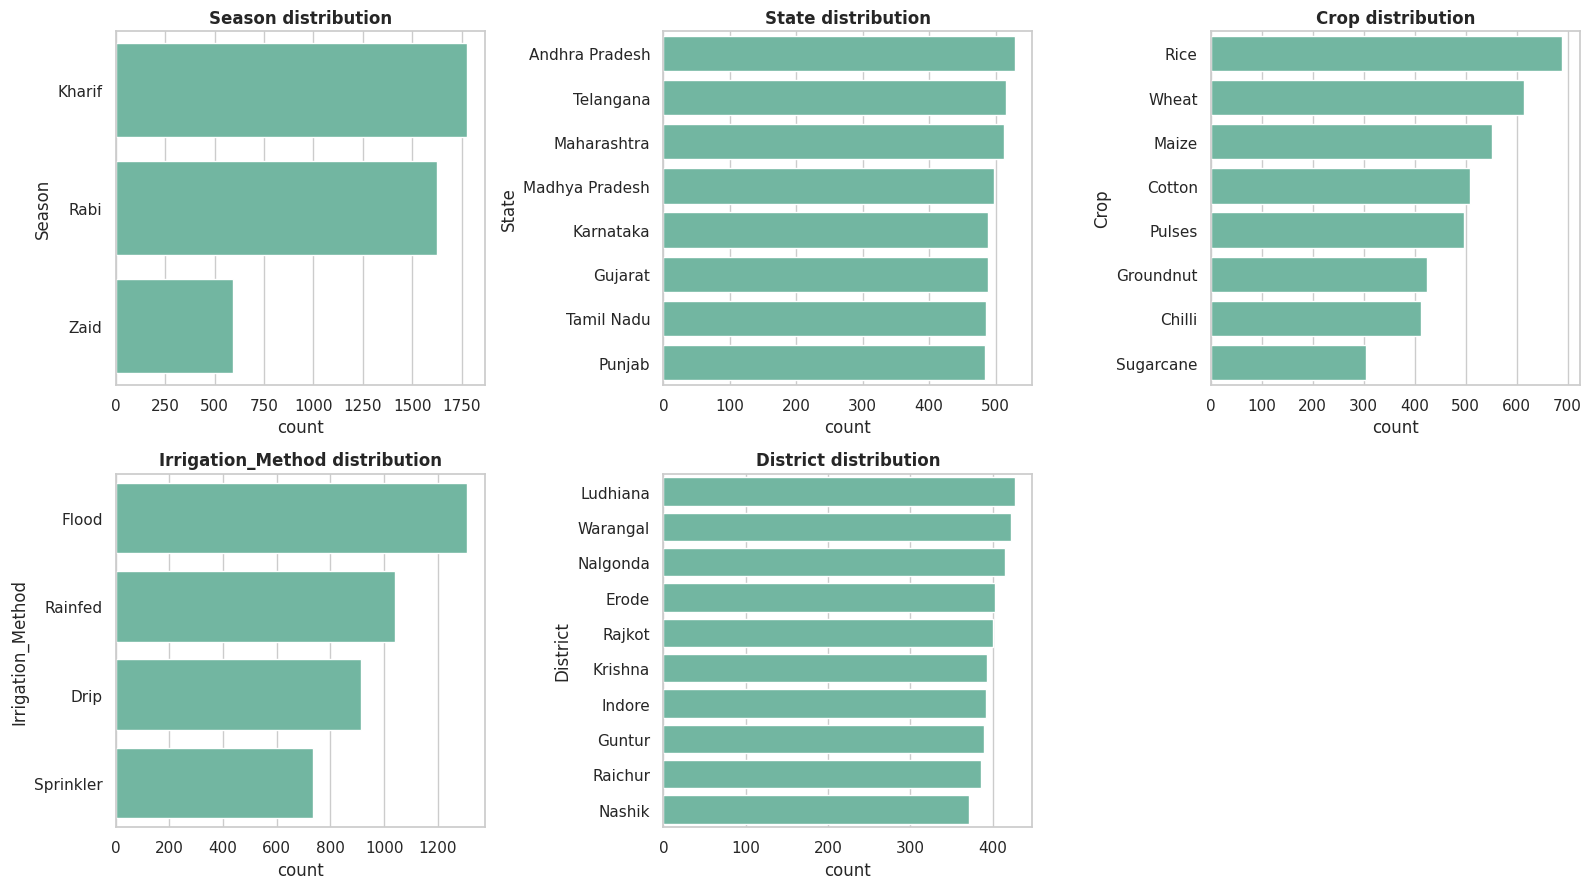

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, ['Season', 'State', 'Crop', 'Irrigation_Method', 'District']):
    order = df_clean[col].value_counts().index
    sns.countplot(data=df_clean, y=col, order=order, ax=ax)
    ax.set_title(f'{col} distribution')
axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()

**Observation:** Kharif is the most common season (~44% of records), followed by Rabi
(~41%) and Zaid (~15%) — reflecting that Zaid is a short, dry-season cropping window in
practice. Crops and states are reasonably balanced; Sugarcane has the fewest records of the
8 crops.

### 11.2 Numerical Variables — Distributions

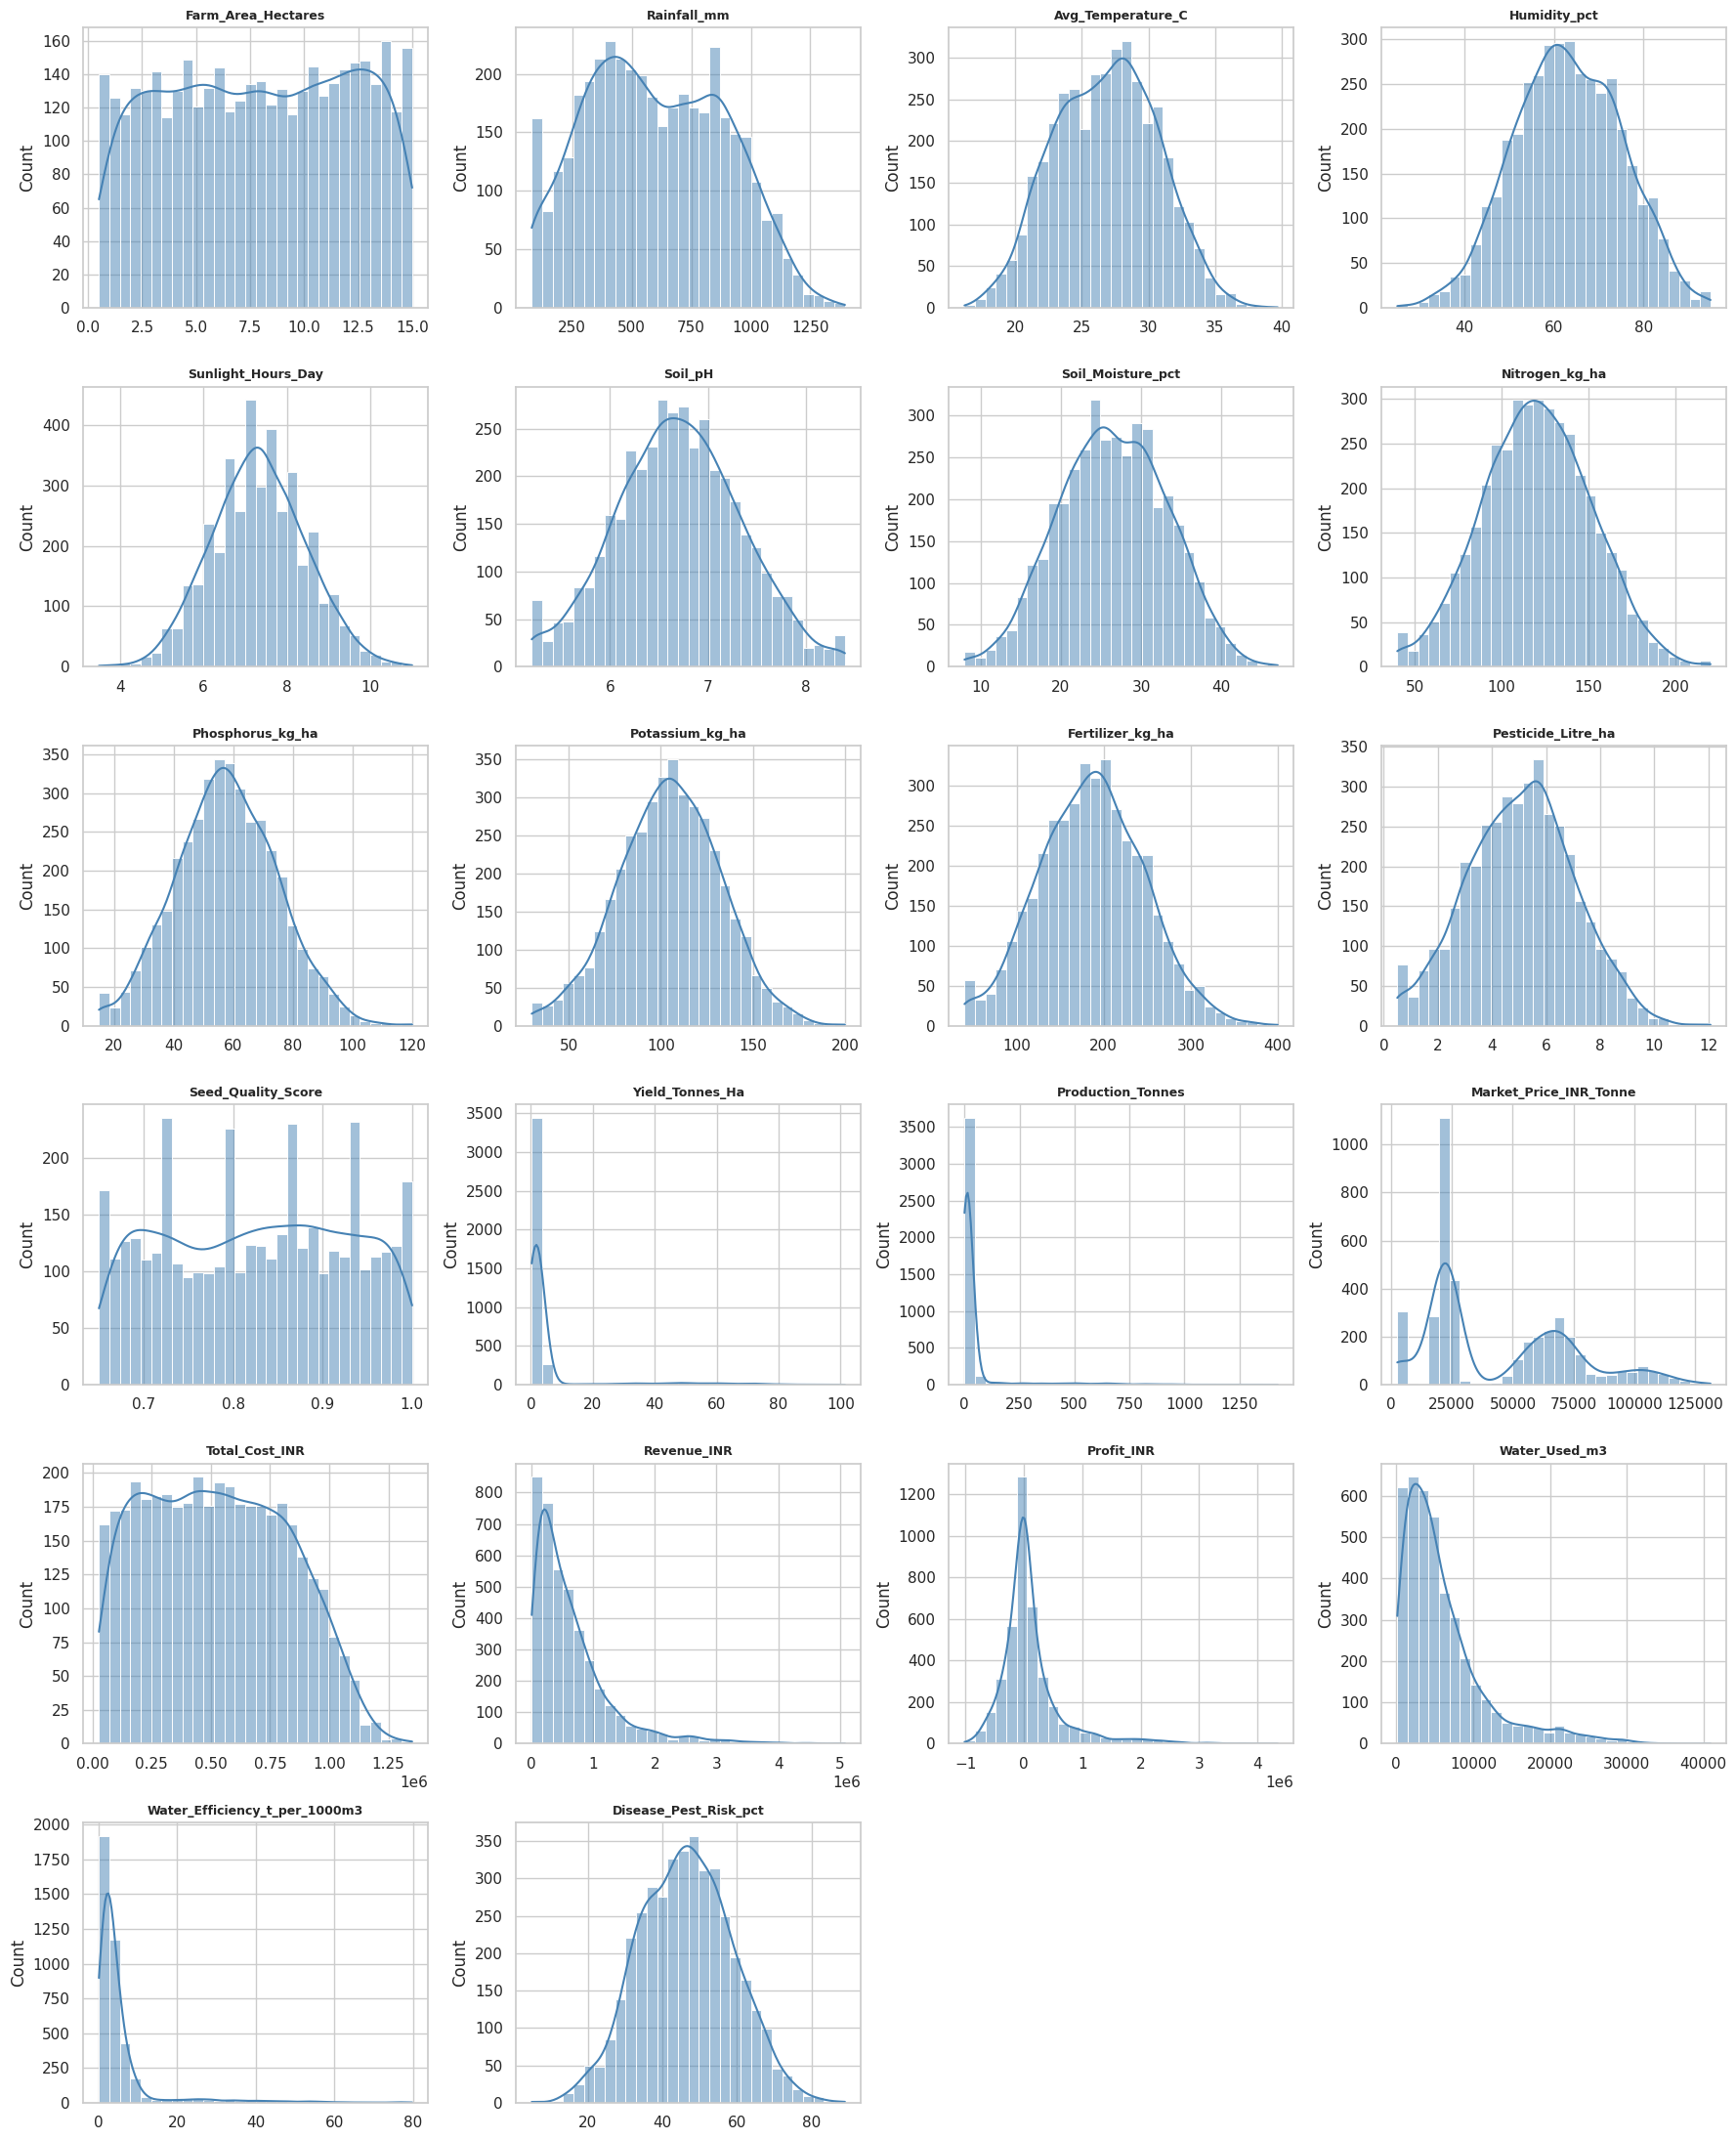

In [26]:
numeric_vars = ['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
                'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
                'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha',
                'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes',
                'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR',
                'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

fig, axes = plt.subplots(6, 4, figsize=(18, 22))
for ax, col in zip(axes.flat, numeric_vars):
    sns.histplot(df_clean[col], bins=30, kde=True, ax=ax, color='steelblue')
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
for ax in axes.flat[len(numeric_vars):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

**Observation:** most environmental and resource-usage variables are approximately
symmetric. `Yield_Tonnes_Ha`, `Production_Tonnes`, and `Water_Efficiency_t_per_1000m3` are
strongly right-skewed — driven by the Sugarcane crop group, as established above. `Profit_INR`
is roughly symmetric but centered close to zero, meaning a large share of farms are close to
break-even.

In [27]:
df_clean[numeric_vars].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.89,4.22,0.50,4.26,7.90,11.65,15.00
Rainfall_mm,4000.0,600.71,288.43,80.00,370.42,581.00,836.12,1395.20
Avg_Temperature_C,4000.0,26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,4000.0,63.21,11.96,25.00,54.78,63.00,71.90,95.00
Sunlight_Hours_Day,4000.0,7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,4000.0,6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,4000.0,26.50,6.70,8.00,21.70,26.40,31.20,47.00
Nitrogen_kg_ha,4000.0,120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,4000.0,57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,4000.0,104.76,27.74,30.00,86.20,105.10,123.60,200.00


## 12. Analytical Questions

The following questions were developed after exploring the dataset, targeting the areas the
project brief asks students to investigate. Each is answered later in the notebook using the
actual calculated values (cross-referenced by section number); this section states the
questions up front.

1. How does average crop yield differ across seasons? → §13
2. Which season has the highest average and total profit? → §16
3. Which season has the highest total production? → §13
4. How does rainfall vary between seasons, and is it associated with yield? → §13, §17
5. Does irrigation method influence yield, water efficiency, or profit? → §19
6. How does water usage and water efficiency differ between seasons? → §13, §21
7. How does disease/pest risk vary across seasons, and what drives it? → §22
8. Does soil moisture relate to yield? → §17, §23
9. Does seed quality relate to yield? → §23, §25
10. How does fertilizer usage relate to yield? → §18, §23
11. Does pesticide usage relate to disease/pest risk? → §22, §23
12. Which crop performs best in each season (yield and profit)? → §15
13. Are seasonal yield patterns consistent across different states? → §16
14. Are there unusual/extreme seasonal records, and what explains them? → §24
15. What do the differences imply for seasonal agricultural planning? → §29

Answers are derived strictly from `df_clean`; no values are assumed in advance.

## 13. Seasonal Performance Analysis

This is the central analysis of the project: how agricultural performance varies across the
three seasons.

In [28]:
season_metrics = df_clean.groupby('Season').agg(
    Num_Farms=('Farm_ID', 'count'),
    Avg_Farm_Area_Ha=('Farm_Area_Hectares', 'mean'),
    Avg_Rainfall_mm=('Rainfall_mm', 'mean'),
    Avg_Temperature_C=('Avg_Temperature_C', 'mean'),
    Avg_Humidity_pct=('Humidity_pct', 'mean'),
    Avg_Sunlight_hrs=('Sunlight_Hours_Day', 'mean'),
    Avg_Soil_Moisture_pct=('Soil_Moisture_pct', 'mean'),
    Avg_Nitrogen_kg_ha=('Nitrogen_kg_ha', 'mean'),
    Avg_Phosphorus_kg_ha=('Phosphorus_kg_ha', 'mean'),
    Avg_Potassium_kg_ha=('Potassium_kg_ha', 'mean'),
    Avg_Fertilizer_kg_ha=('Fertilizer_kg_ha', 'mean'),
    Avg_Pesticide_L_ha=('Pesticide_Litre_ha', 'mean'),
    Avg_Seed_Quality=('Seed_Quality_Score', 'mean'),
    Avg_Yield_t_ha=('Yield_Tonnes_Ha', 'mean'),
    Total_Production_t=('Production_Tonnes', 'sum'),
    Avg_Production_t=('Production_Tonnes', 'mean'),
    Avg_Market_Price=('Market_Price_INR_Tonne', 'mean'),
    Total_Cost_INR=('Total_Cost_INR', 'sum'),
    Total_Revenue_INR=('Revenue_INR', 'sum'),
    Total_Profit_INR=('Profit_INR', 'sum'),
    Avg_Profit_INR=('Profit_INR', 'mean'),
    Avg_Water_Used_m3=('Water_Used_m3', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Disease_Pest_Risk_pct=('Disease_Pest_Risk_pct', 'mean'),
).round(2).reindex(SEASON_ORDER)

season_metrics

,Num_Farms,Avg_Farm_Area_Ha,Avg_Rainfall_mm,Avg_Temperature_C,Avg_Humidity_pct,Avg_Sunlight_hrs,Avg_Soil_Moisture_pct,Avg_Nitrogen_kg_ha,Avg_Phosphorus_kg_ha,Avg_Potassium_kg_ha,Avg_Fertilizer_kg_ha,Avg_Pesticide_L_ha,Avg_Seed_Quality,Avg_Yield_t_ha,Total_Production_t,Avg_Production_t,Avg_Market_Price,Total_Cost_INR,Total_Revenue_INR,Total_Profit_INR,Avg_Profit_INR,Avg_Water_Used_m3,Avg_Water_Efficiency,Avg_Disease_Pest_Risk_pct
Season,,,,,,,,,,,,,,,,,,,,,,,,
Kharif,1779,7.94,852.11,28.45,71.81,6.79,31.20,120.02,58.10,105.30,187.08,5.08,0.82,5.63,82387.61,46.31,44850.91,946080042,1264369200,318289158,178914.65,6102.20,5.89,54.47
Rabi,1627,7.75,435.94,23.49,57.89,7.59,24.05,120.40,57.31,103.93,185.41,5.02,0.83,5.10,67498.88,41.49,44747.97,836012113,978682881,142670768,87689.47,5846.99,5.19,40.48
Zaid,594,8.09,299.12,31.04,52.01,8.18,19.17,120.53,58.13,105.42,184.64,5.17,0.82,4.64,23098.35,38.89,44212.03,323122177,308388111,-14734066,-24804.82,6419.89,4.41,38.22


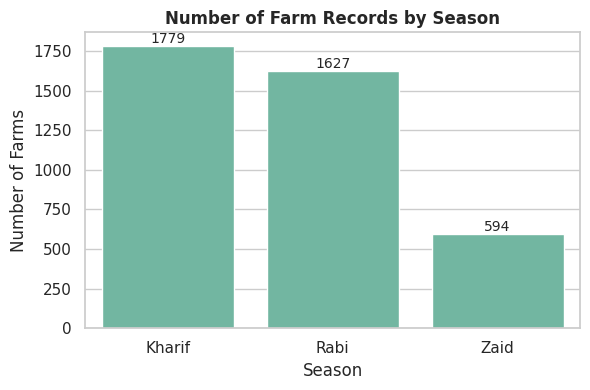

In [29]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df_clean, x='Season', order=SEASON_ORDER, ax=ax)
ax.set_title('Number of Farm Records by Season'); ax.set_xlabel('Season'); ax.set_ylabel('Number of Farms')
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.tight_layout(); plt.show()

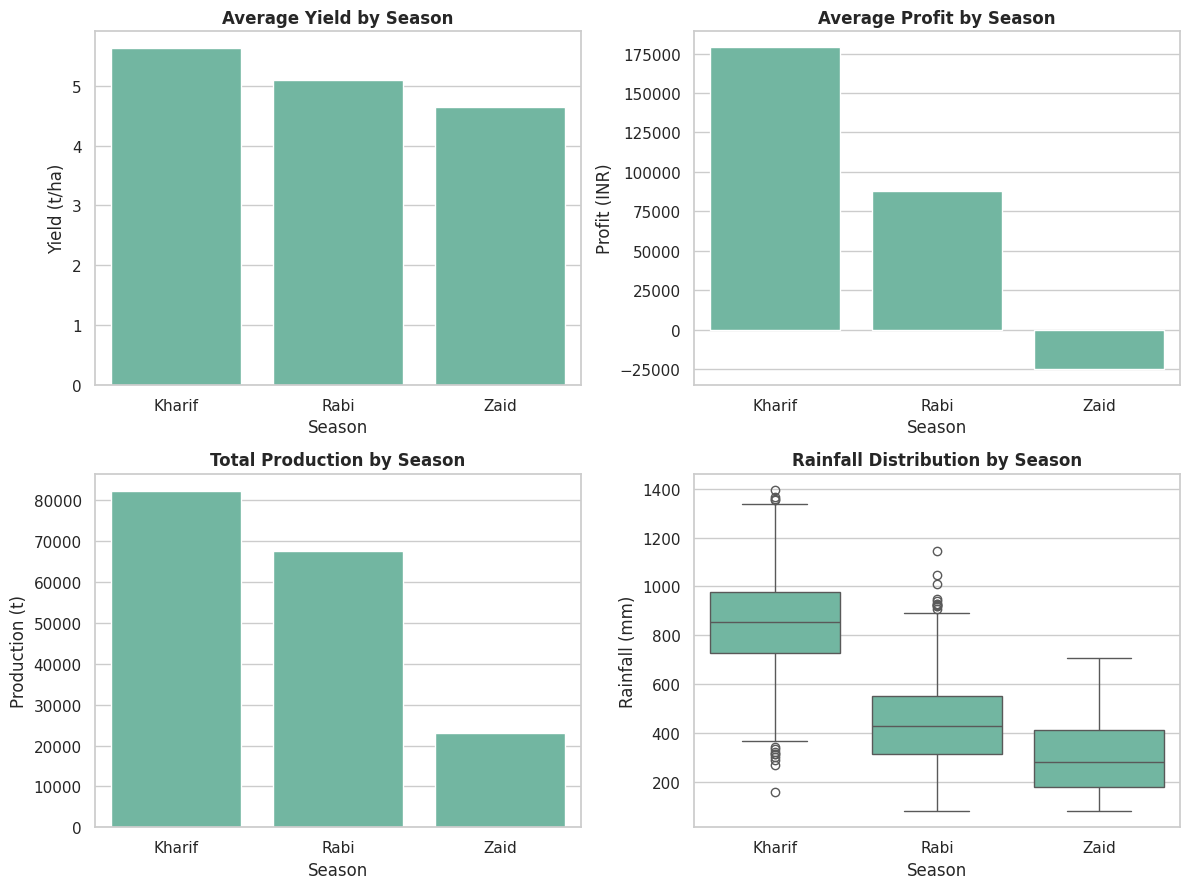

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
sns.barplot(data=df_clean, x='Season', y='Yield_Tonnes_Ha', order=SEASON_ORDER, estimator=np.mean, errorbar=None, ax=axes[0,0])
axes[0,0].set_title('Average Yield by Season'); axes[0,0].set_ylabel('Yield (t/ha)')
sns.barplot(data=df_clean, x='Season', y='Profit_INR', order=SEASON_ORDER, estimator=np.mean, errorbar=None, ax=axes[0,1])
axes[0,1].set_title('Average Profit by Season'); axes[0,1].set_ylabel('Profit (INR)')
sns.barplot(data=df_clean, x='Season', y='Production_Tonnes', order=SEASON_ORDER, estimator=np.sum, errorbar=None, ax=axes[1,0])
axes[1,0].set_title('Total Production by Season'); axes[1,0].set_ylabel('Production (t)')
sns.boxplot(data=df_clean, x='Season', y='Rainfall_mm', order=SEASON_ORDER, ax=axes[1,1])
axes[1,1].set_title('Rainfall Distribution by Season'); axes[1,1].set_ylabel('Rainfall (mm)')
plt.tight_layout(); plt.show()

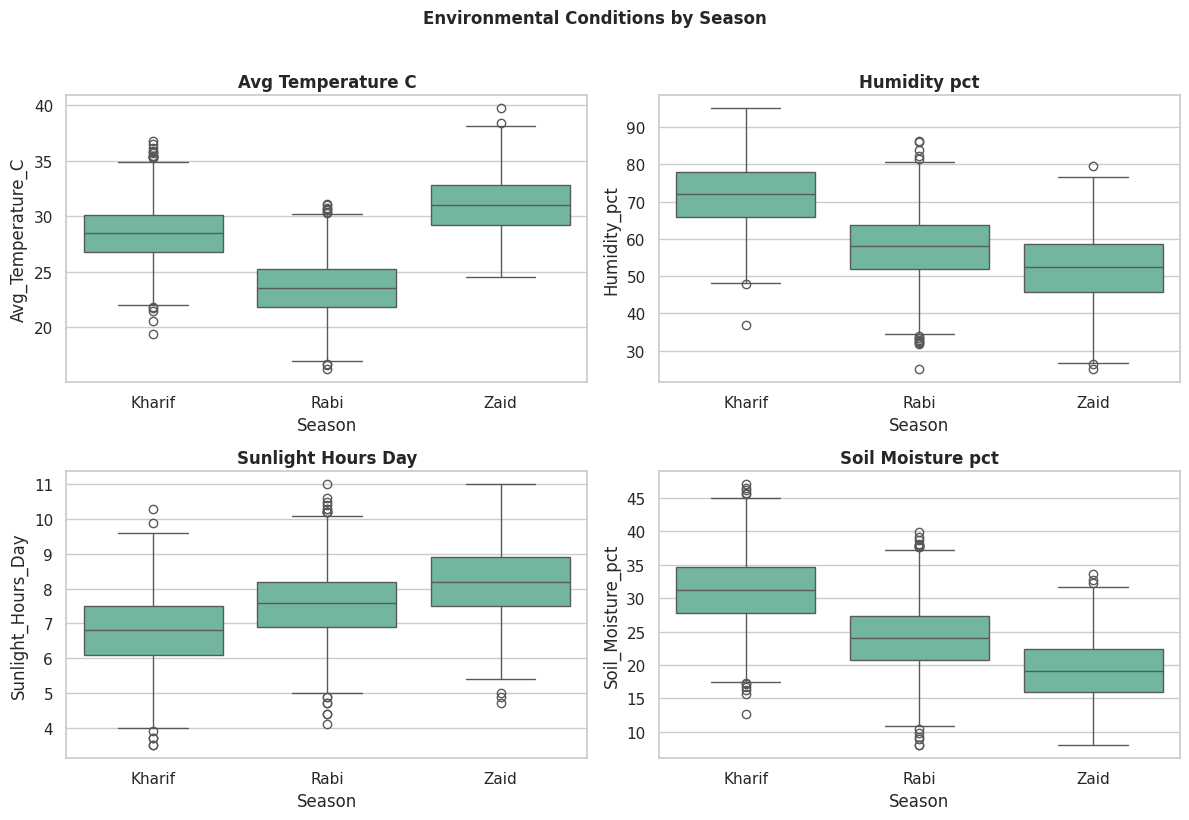

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, var in zip(axes.flat, ['Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_Moisture_pct']):
    sns.boxplot(data=df_clean, x='Season', y=var, order=SEASON_ORDER, ax=ax)
    ax.set_title(var.replace('_', ' '))
plt.suptitle('Environmental Conditions by Season', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

**Key seasonal observations (values read directly from the table above):**
- Kharif — the monsoon season — receives by far the highest rainfall and humidity of the three
  seasons, consistent with it being India's principal monsoon cropping season.
- Zaid, the short dry-season window, shows the lowest rainfall and the fewest farm records,
  consistent with it being a smaller, irrigation-dependent cropping window.
- Average yield, profit, and disease/pest risk all differ across seasons; the size and
  statistical significance of these differences are tested formally in §23.

## 14. Crop-wise Seasonal Analysis (Season x Crop)

In [32]:
sc_yield = df_clean.pivot_table(index='Crop', columns='Season', values='Yield_Tonnes_Ha', aggfunc='mean').reindex(columns=SEASON_ORDER)
sc_profit = df_clean.pivot_table(index='Crop', columns='Season', values='Profit_INR', aggfunc='mean').reindex(columns=SEASON_ORDER)
sc_revenue = df_clean.pivot_table(index='Crop', columns='Season', values='Revenue_INR', aggfunc='mean').reindex(columns=SEASON_ORDER)
sc_production = df_clean.pivot_table(index='Crop', columns='Season', values='Production_Tonnes', aggfunc='sum').reindex(columns=SEASON_ORDER)
sc_watereff = df_clean.pivot_table(index='Crop', columns='Season', values='Water_Efficiency_t_per_1000m3', aggfunc='mean').reindex(columns=SEASON_ORDER)
sc_risk = df_clean.pivot_table(index='Crop', columns='Season', values='Disease_Pest_Risk_pct', aggfunc='mean').reindex(columns=SEASON_ORDER)

print('Average Yield (t/ha) by Season x Crop:'); display(sc_yield.round(2))

Average Yield (t/ha) by Season x Crop:


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.19
Cotton,1.37,1.19,0.95
Groundnut,1.48,1.23,1.04
Maize,2.97,2.62,2.30
Pulses,1.04,0.87,0.66
Rice,2.71,2.34,1.90
Sugarcane,53.46,44.00,38.42
Wheat,2.26,2.06,1.75


In [33]:
print('Average Profit (INR) by Season x Crop:'); display(sc_profit.round(0))

Average Profit (INR) by Season x Crop:


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,954380.0,638572.0,448659.0
Cotton,217000.0,107344.0,-53925.0
Groundnut,108265.0,10417.0,-68872.0
Maize,-39333.0,-89133.0,-194049.0
Pulses,43339.0,-14309.0,-139228.0
Rice,-64903.0,-98428.0,-227239.0
Sugarcane,1000791.0,731613.0,583636.0
Wheat,-105872.0,-119955.0,-193209.0


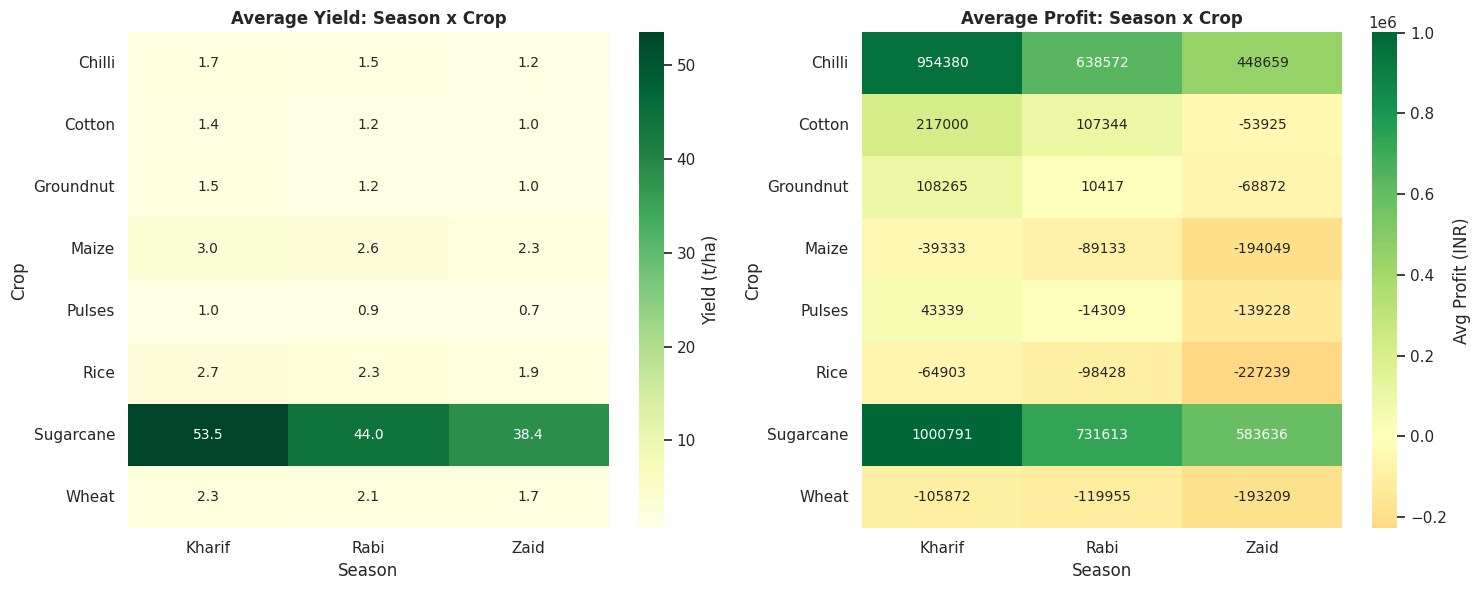

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(sc_yield, annot=True, fmt='.1f', cmap='YlGn', ax=axes[0], cbar_kws={'label': 'Yield (t/ha)'})
axes[0].set_title('Average Yield: Season x Crop')
sns.heatmap(sc_profit, annot=True, fmt='.0f', cmap='RdYlGn', center=0, ax=axes[1], cbar_kws={'label': 'Avg Profit (INR)'})
axes[1].set_title('Average Profit: Season x Crop')
plt.tight_layout(); plt.show()

In [35]:
best_yield = sc_yield.stack().idxmax(); worst_yield = sc_yield.stack().idxmin()
best_profit = sc_profit.stack().idxmax(); worst_profit = sc_profit.stack().idxmin()
print(f'Best-performing Season x Crop combination by yield: {best_yield[0]} in {best_yield[1]} ({sc_yield.stack().max():.2f} t/ha)')
print(f'Lowest-yield combination: {worst_yield[0]} in {worst_yield[1]} ({sc_yield.stack().min():.2f} t/ha)')
print(f'Most profitable combination: {best_profit[0]} in {best_profit[1]} (avg profit {sc_profit.stack().max():,.0f} INR)')
print(f'Least profitable combination: {worst_profit[0]} in {worst_profit[1]} (avg profit {sc_profit.stack().min():,.0f} INR)')

Best-performing Season x Crop combination by yield: Sugarcane in Kharif (53.46 t/ha)
Lowest-yield combination: Pulses in Zaid (0.66 t/ha)
Most profitable combination: Sugarcane in Kharif (avg profit 1,000,791 INR)
Least profitable combination: Rice in Zaid (avg profit -227,239 INR)


**Note:** Sugarcane dominates the yield heatmap by a wide margin in every season because
of its inherently higher yield scale (see §10), so yield comparisons *between other crops* are
more informative when read independently of the Sugarcane row. The profit heatmap is not
subject to the same scale distortion and is directly comparable across all crops.

In [36]:
print('Production (t) by Season x Crop:'); display(sc_production.round(1))
print()
print('Water efficiency (t/1000 m3) by Season x Crop:'); display(sc_watereff.round(2))
print()
print('Disease/pest risk (%) by Season x Crop:'); display(sc_risk.round(2))

Production (t) by Season x Crop:


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,2675.7,1787.4,638.6
Cotton,2237.8,1897.6,637.6
Groundnut,2024.6,1603.9,465.6
Maize,5463.5,5030.8,1507.1
Pulses,1831.4,1533.3,306.5
Rice,7049.2,4719.2,1540.7
Sugarcane,55759.4,47119.0,16807.6
Wheat,5346.0,3807.6,1194.7



Water efficiency (t/1000 m3) by Season x Crop:


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,3.26,2.89,2.20
Cotton,2.13,1.94,1.49
Groundnut,3.58,2.90,2.47
Maize,6.05,5.46,4.75
Pulses,3.35,2.70,1.95
Rice,2.17,1.84,1.53
Sugarcane,36.00,27.92,23.39
Wheat,4.76,4.69,4.02



Disease/pest risk (%) by Season x Crop:


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,52.81,40.59,40.50
Cotton,54.24,41.54,36.34
Groundnut,54.28,39.76,39.13
Maize,54.82,39.41,36.68
Pulses,54.96,40.08,38.97
Rice,54.25,40.79,37.95
Sugarcane,54.02,39.85,38.35
Wheat,55.58,41.46,39.16


## 15. Regional Analysis (Season x State)

Because `District` does not map uniquely to `State` in this dataset (§8), regional analysis is
reported at the **State** level, where the grouping is unambiguous.

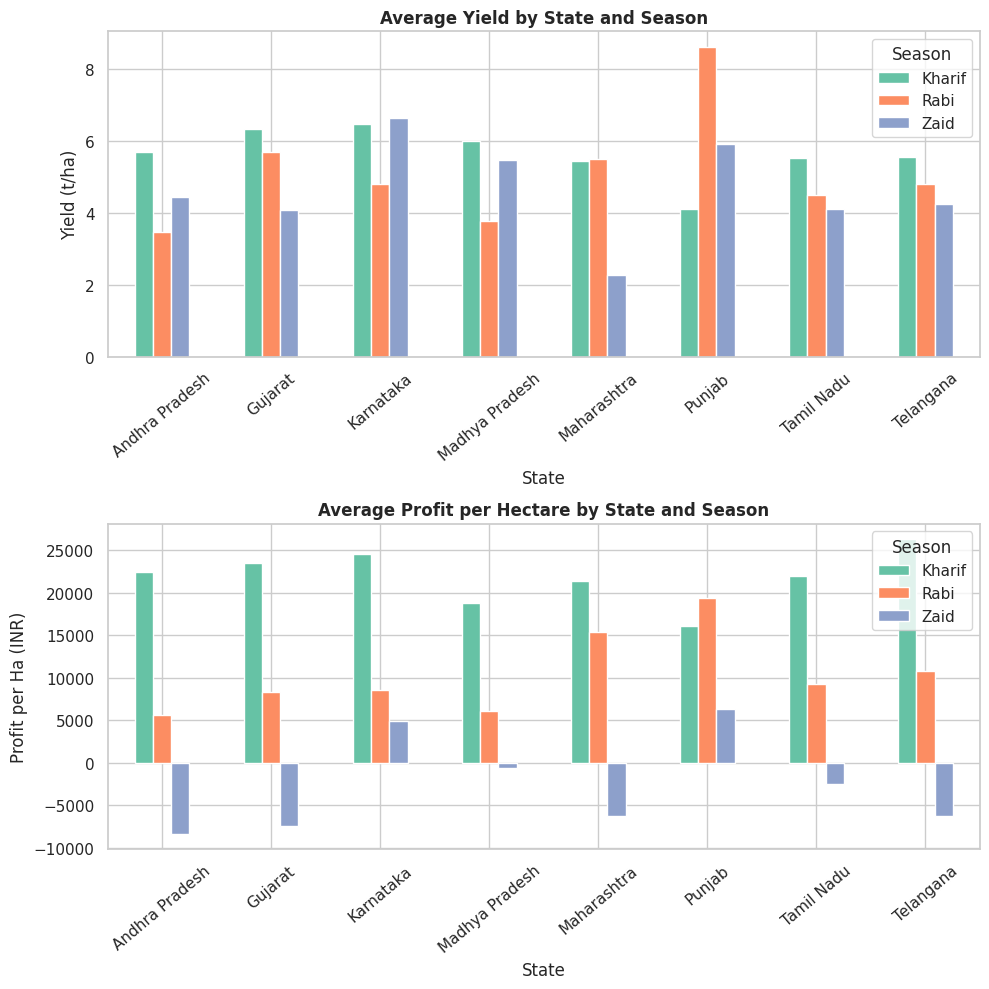

In [37]:
ss_yield = df_clean.pivot_table(index='State', columns='Season', values='Yield_Tonnes_Ha', aggfunc='mean').reindex(columns=SEASON_ORDER)
ss_profit_ha = df_clean.pivot_table(index='State', columns='Season', values='Profit_per_Ha', aggfunc='mean').reindex(columns=SEASON_ORDER)

fig, axes = plt.subplots(2, 1, figsize=(10, 10))
ss_yield.plot(kind='bar', ax=axes[0])
axes[0].set_title('Average Yield by State and Season'); axes[0].set_ylabel('Yield (t/ha)')
axes[0].tick_params(axis='x', rotation=40)
ss_profit_ha.plot(kind='bar', ax=axes[1])
axes[1].set_title('Average Profit per Hectare by State and Season'); axes[1].set_ylabel('Profit per Ha (INR)')
axes[1].tick_params(axis='x', rotation=40)
plt.tight_layout(); plt.show()

In [38]:
# Consistency check: how much does each state's seasonal yield pattern vary (coefficient of variation)?
state_season_cv = (ss_yield.std(axis=1) / ss_yield.mean(axis=1) * 100).round(2).sort_values()
print('Coefficient of variation (%) of average yield across seasons, by State (lower = more consistent):')
print(state_season_cv)
print(f"\nMost consistent state across seasons: {state_season_cv.index[0]}")
print(f"Least consistent state across seasons: {state_season_cv.index[-1]}")

Coefficient of variation (%) of average yield across seasons, by State (lower = more consistent):
State
Telangana         13.46
Tamil Nadu        15.59
Karnataka         16.97
Gujarat           21.61
Madhya Pradesh    22.94
Andhra Pradesh    24.46
Punjab            36.56
Maharashtra       41.93
dtype: float64

Most consistent state across seasons: Telangana
Least consistent state across seasons: Maharashtra


**Observation:** average yield by season differs somewhat across states, but the overall
seasonal ranking (which season tends to have higher/lower yield) is broadly similar across most
states — differences in the *level* of yield between states are larger than differences in the
*seasonal pattern* itself. This is examined statistically together with the crop mix in
§23 (Season × Irrigation / Season × Crop association tests).

## 16. Environmental Analysis

Relationships between environmental conditions and agricultural outcomes.
**Correlation does not prove causation** — these results describe association only.

In [39]:
env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct']
outcome_cols = ['Yield_Tonnes_Ha', 'Production_Tonnes', 'Revenue_INR', 'Profit_INR',
                'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

env_outcome_corr = df_clean[env_cols + outcome_cols].corr(method='pearson').loc[env_cols, outcome_cols]
env_outcome_corr.round(3)

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Rainfall_mm,0.027,0.023,0.098,0.106,0.057,0.624
Avg_Temperature_C,0.009,0.007,0.027,0.009,0.007,0.246
Humidity_pct,0.011,0.004,0.057,0.064,0.026,0.545
Sunlight_Hours_Day,-0.015,-0.024,-0.047,-0.055,-0.021,-0.253
Soil_pH,-0.022,-0.013,-0.009,-0.013,-0.010,0.031
Soil_Moisture_pct,0.010,0.005,0.080,0.092,0.028,0.379


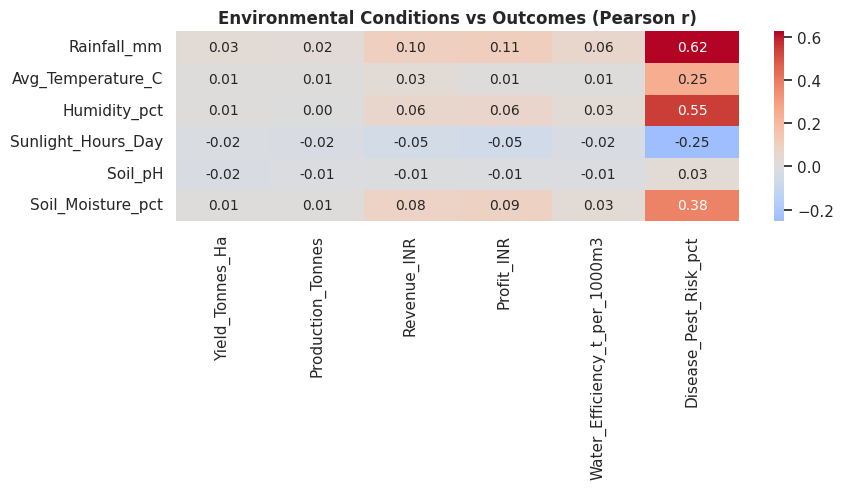

In [40]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(env_outcome_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Environmental Conditions vs Outcomes (Pearson r)')
plt.tight_layout(); plt.show()

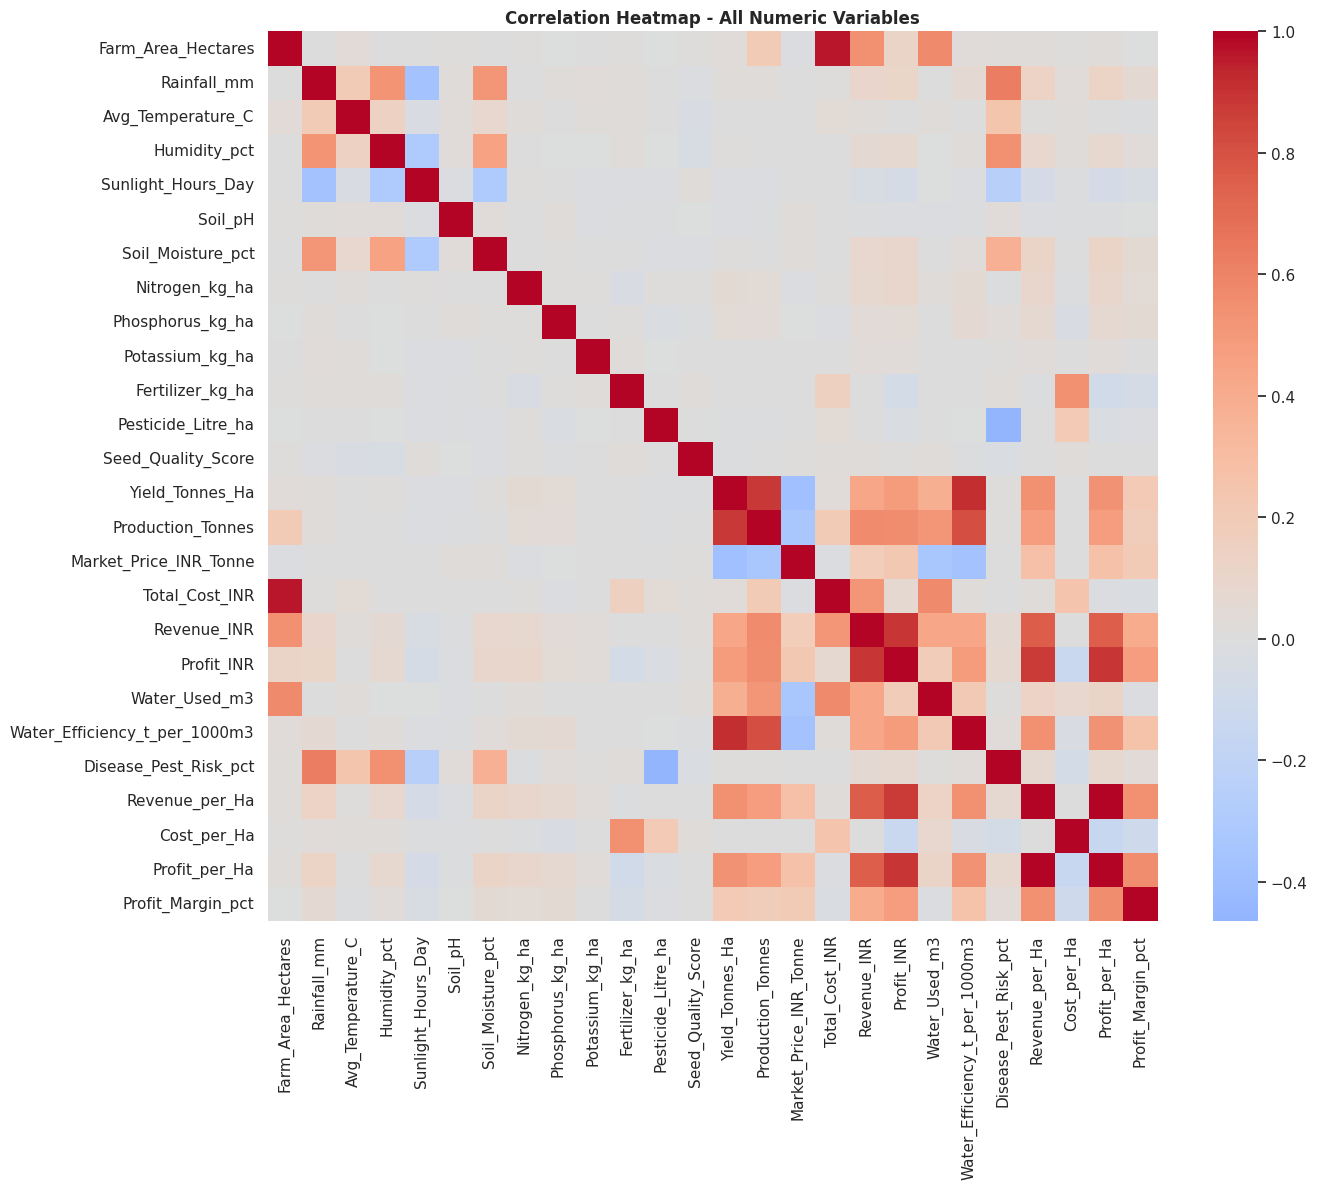

In [41]:
full_corr = df_clean.select_dtypes(include=[np.number]).corr()
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(full_corr, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap - All Numeric Variables')
plt.tight_layout(); plt.show()

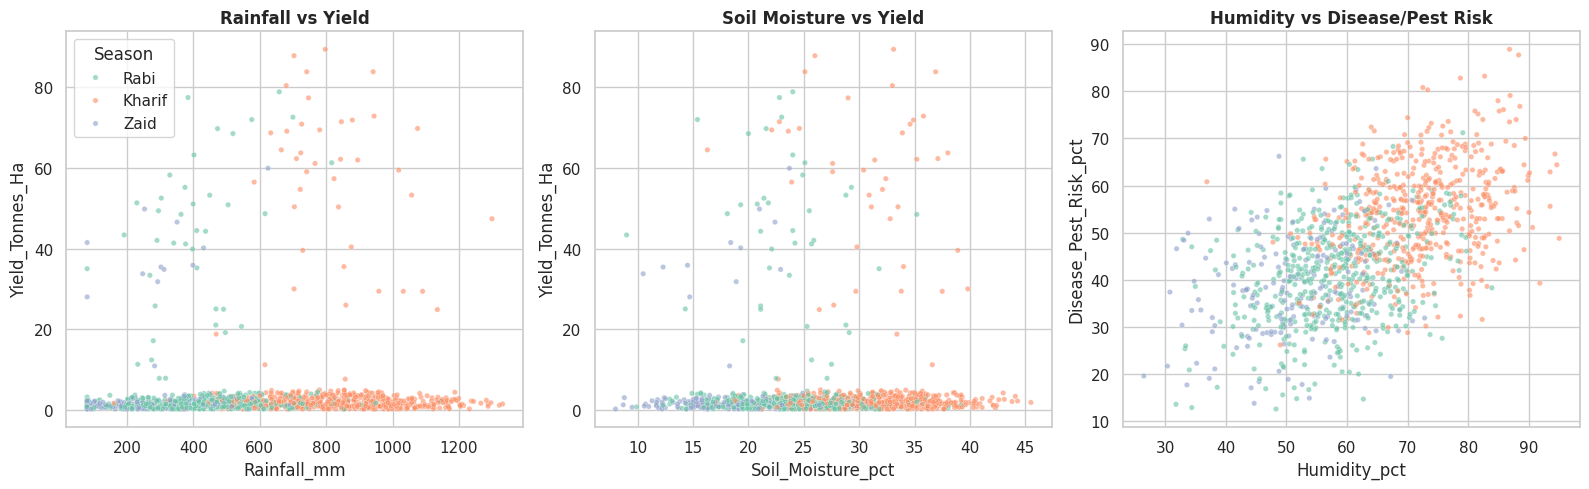

In [42]:
sample = df_clean.sample(1200, random_state=42)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.scatterplot(data=sample, x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season', ax=axes[0], s=15, alpha=0.6)
axes[0].set_title('Rainfall vs Yield')
sns.scatterplot(data=sample, x='Soil_Moisture_pct', y='Yield_Tonnes_Ha', hue='Season', ax=axes[1], s=15, alpha=0.6, legend=False)
axes[1].set_title('Soil Moisture vs Yield')
sns.scatterplot(data=sample, x='Humidity_pct', y='Disease_Pest_Risk_pct', hue='Season', ax=axes[2], s=15, alpha=0.6, legend=False)
axes[2].set_title('Humidity vs Disease/Pest Risk')
plt.tight_layout(); plt.show()

**Interpretation:** correlations between individual environmental variables and yield are
weak in magnitude (see §23 for exact coefficients and significance) — expected, since yield
here is driven far more strongly by which crop is grown than by small variations in weather
within a season. Humidity shows a positive association with disease/pest risk, consistent with
the agronomic expectation that damp conditions favor fungal and pest pressure — but this is an
association, not proof that humidity alone causes higher risk, since it is also correlated with
season and rainfall.

## 17. Resource Usage Analysis

In [43]:
resource_cols = ['Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Water_Used_m3']
resource_by_season = df_clean.groupby('Season')[resource_cols].mean().round(2).reindex(SEASON_ORDER)
resource_by_season

,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3
Season,,,,,,
Kharif,120.02,58.10,105.30,187.08,5.08,6102.20
Rabi,120.40,57.31,103.93,185.41,5.02,5846.99
Zaid,120.53,58.13,105.42,184.64,5.17,6419.89


In [44]:
resource_outcome_corr = df_clean[resource_cols + ['Yield_Tonnes_Ha', 'Profit_INR', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']].corr()
resource_outcome_corr.loc[resource_cols, ['Yield_Tonnes_Ha', 'Profit_INR', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']].round(3)

,Yield_Tonnes_Ha,Profit_INR,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Nitrogen_kg_ha,0.054,0.085,0.055,-0.012
Phosphorus_kg_ha,0.047,0.050,0.057,0.032
Potassium_kg_ha,0.005,0.031,0.007,0.013
Fertilizer_kg_ha,-0.000,-0.074,0.005,0.018
Pesticide_Litre_ha,-0.009,-0.026,-0.006,-0.465
Water_Used_m3,0.387,0.190,0.217,0.011


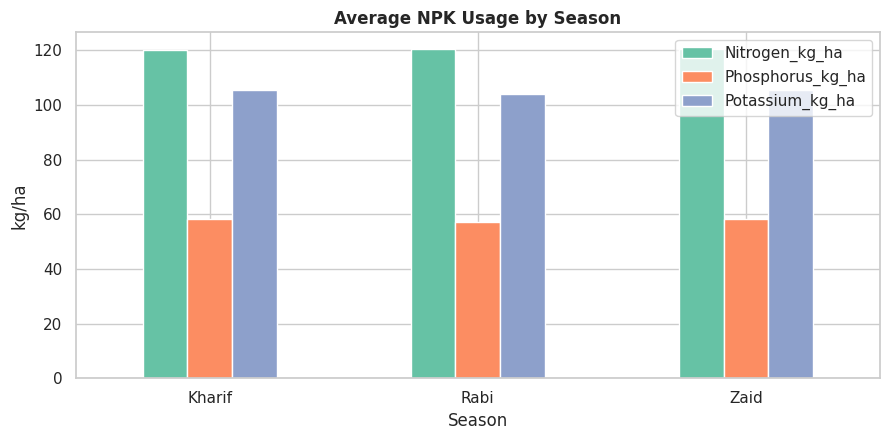

In [45]:
fig, ax = plt.subplots(figsize=(9, 4.5))
resource_by_season[['Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha']].plot(kind='bar', ax=ax)
ax.set_title('Average NPK Usage by Season'); ax.set_ylabel('kg/ha'); ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

**Observation:** resource-usage levels (fertilizer, pesticide, water) are broadly similar
across seasons, with the correlations against yield, profit, and disease risk all weak in
magnitude — resource *quantity* alone does not strongly predict outcome in this dataset; timing,
crop choice, and environmental conditions appear to matter more (see the regression in §25).

## 18. Irrigation Analysis

In [46]:
irr_metrics = df_clean.groupby('Irrigation_Method').agg(
    Num_Farms=('Farm_ID', 'count'), Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Profit=('Profit_INR', 'mean'), Avg_Water_Used=('Water_Used_m3', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Disease_Risk=('Disease_Pest_Risk_pct', 'mean'),
).round(2).sort_values('Avg_Water_Efficiency', ascending=False)
irr_metrics

,Num_Farms,Avg_Yield,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency,Avg_Disease_Risk
Irrigation_Method,,,,,,
Rainfed,1041,4.60,79050.37,3549.55,7.56,46.49
Drip,915,6.68,219626.00,5918.75,6.27,45.79
Sprinkler,734,5.16,91121.08,6208.26,4.67,46.48
Flood,1310,4.86,73354.02,8026.47,3.44,46.60


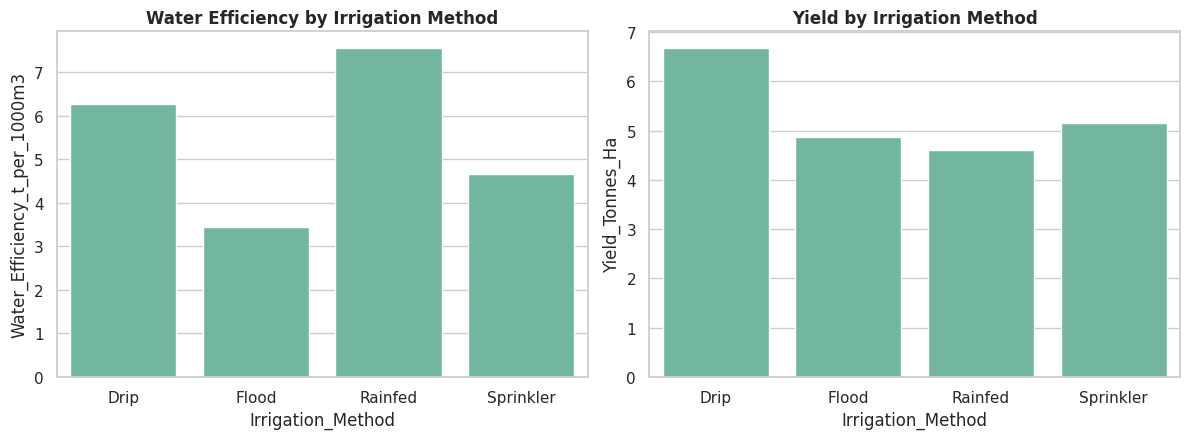

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(data=df_clean, x='Irrigation_Method', y='Water_Efficiency_t_per_1000m3', errorbar=None, ax=axes[0])
axes[0].set_title('Water Efficiency by Irrigation Method')
sns.barplot(data=df_clean, x='Irrigation_Method', y='Yield_Tonnes_Ha', errorbar=None, ax=axes[1])
axes[1].set_title('Yield by Irrigation Method')
plt.tight_layout(); plt.show()

In [48]:
irr_groups = [g['Water_Efficiency_t_per_1000m3'].values for _, g in df_clean.groupby('Irrigation_Method')]
h_stat, p_val = stats.kruskal(*irr_groups)
print(f'Kruskal-Wallis test - water efficiency across irrigation methods: H={h_stat:.2f}, p={p_val:.4g}')
print('Significant difference across irrigation methods.' if p_val < ALPHA else 'No significant difference detected.')

Kruskal-Wallis test - water efficiency across irrigation methods: H=573.86, p=4.671e-124
Significant difference across irrigation methods.


**Interpretation:** irrigation methods differ in average water efficiency (statistically
significant per the Kruskal-Wallis test above). This is an **observational association** —
farmers may also choose irrigation method based on crop, region, or water availability — so it
should not be read as "switching irrigation method causes higher efficiency" without controlling
for those factors.

## 19. Economic Performance Analysis

In [49]:
econ_by_season = df_clean.groupby('Season').agg(
    Avg_Revenue=('Revenue_INR', 'mean'), Avg_Cost=('Total_Cost_INR', 'mean'), Avg_Profit=('Profit_INR', 'mean'),
    Total_Revenue=('Revenue_INR', 'sum'), Total_Cost=('Total_Cost_INR', 'sum'), Total_Profit=('Profit_INR', 'sum'),
    Avg_Revenue_per_Ha=('Revenue_per_Ha', 'mean'), Avg_Cost_per_Ha=('Cost_per_Ha', 'mean'),
    Avg_Profit_per_Ha=('Profit_per_Ha', 'mean'), Avg_Profit_Margin_pct=('Profit_Margin_pct', 'mean'),
    Pct_Loss_Making_Farms=('Profit_INR', lambda s: (s < 0).mean() * 100),
).round(2).reindex(SEASON_ORDER)
econ_by_season

,Avg_Revenue,Avg_Cost,Avg_Profit,Total_Revenue,Total_Cost,Total_Profit,Avg_Revenue_per_Ha,Avg_Cost_per_Ha,Avg_Profit_per_Ha,Avg_Profit_Margin_pct,Pct_Loss_Making_Farms
Season,,,,,,,,,,,
Kharif,710719.06,531804.41,178914.65,1264369200,946080042,318289158,88782.79,66900.98,21881.81,-38.64,42.21
Rabi,601526.05,513836.58,87689.47,978682881,836012113,142670768,76656.92,66295.24,10361.68,-44.27,51.14
Zaid,519171.90,543976.73,-24804.82,308388111,323122177,-14734066,64301.42,66937.94,-2636.52,-69.35,64.48


**Derived-metric definitions:** `Profit_per_Ha = Profit_INR / Farm_Area_Hectares`,
similarly for Revenue and Cost per hectare; `Profit_Margin_pct = Profit_INR / Revenue_INR x 100`.
The Revenue − Total Cost = Profit identity was verified to hold exactly for every record (§8),
so no inconsistencies needed to be resolved here.

Overall share of farm records operating at a loss: 49.1%


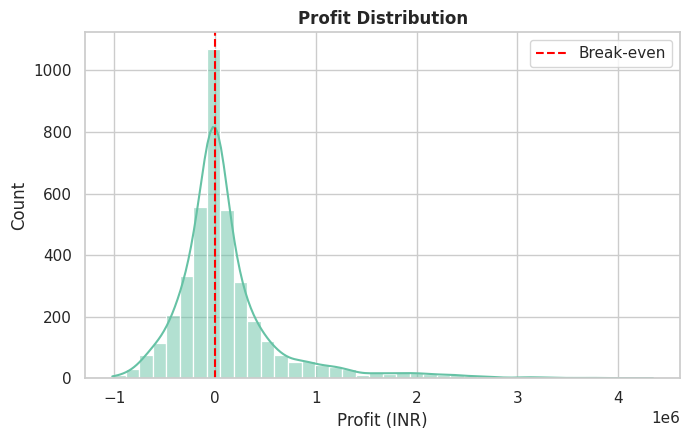

In [50]:
print(f"Overall share of farm records operating at a loss: {(df_clean['Profit_INR'] < 0).mean()*100:.1f}%")

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.histplot(df_clean['Profit_INR'], bins=40, kde=True, ax=ax)
ax.axvline(0, color='red', linestyle='--', label='Break-even')
ax.set_title('Profit Distribution'); ax.set_xlabel('Profit (INR)'); ax.legend()
plt.tight_layout(); plt.show()

## 20. Water Efficiency Analysis

In [51]:
we_by_season = df_clean.groupby('Season')['Water_Efficiency_t_per_1000m3'].mean().reindex(SEASON_ORDER).round(2)
we_by_crop = df_clean.groupby('Crop')['Water_Efficiency_t_per_1000m3'].mean().sort_values(ascending=False).round(2)
we_by_irrigation = df_clean.groupby('Irrigation_Method')['Water_Efficiency_t_per_1000m3'].mean().sort_values(ascending=False).round(2)
we_by_state = df_clean.groupby('State')['Water_Efficiency_t_per_1000m3'].mean().sort_values(ascending=False).round(2)

print('By Season:'); print(we_by_season)
print('\nBy Crop:'); print(we_by_crop)
print('\nBy Irrigation Method:'); print(we_by_irrigation)
print('\nBy State:'); print(we_by_state)

By Season:
Season
Kharif    5.89
Rabi      5.19
Zaid      4.41
Name: Water_Efficiency_t_per_1000m3, dtype: float64

By Crop:
Crop
Sugarcane    30.48
Maize         5.60
Wheat         4.63
Groundnut     3.15
Chilli        2.95
Pulses        2.90
Rice          1.95
Cotton        1.94
Name: Water_Efficiency_t_per_1000m3, dtype: float64

By Irrigation Method:
Irrigation_Method
Rainfed      7.56
Drip         6.27
Sprinkler    4.67
Flood        3.44
Name: Water_Efficiency_t_per_1000m3, dtype: float64

By State:
State
Punjab            5.62
Gujarat           5.58
Karnataka         5.56
Telangana         5.46
Tamil Nadu        5.31
Maharashtra       5.28
Madhya Pradesh    5.27
Andhra Pradesh    5.03
Name: Water_Efficiency_t_per_1000m3, dtype: float64


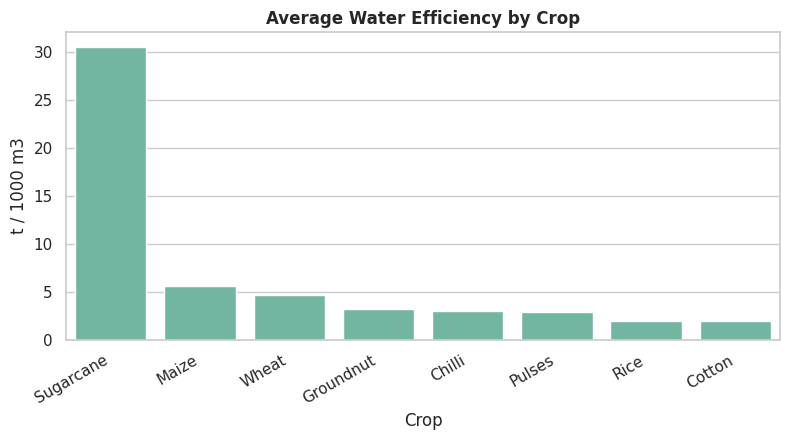

In [52]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=we_by_crop.index, y=we_by_crop.values, ax=ax)
ax.set_title('Average Water Efficiency by Crop'); ax.set_ylabel('t / 1000 m3')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

**Observation:** Sugarcane again stands out with the highest water efficiency in absolute
terms, consistent with its much higher yield per hectare, even though it is also a
water-intensive crop in absolute `Water_Used_m3` terms. Among irrigation methods, the ranking
above indicates which method converts water into production most effectively in this dataset;
Drip and Sprinkler systems are generally understood to be more water-efficient than Flood
irrigation, which the data can be checked against directly.

## 21. Disease and Pest Risk Analysis

In [53]:
risk_by_season = df_clean.groupby('Season')['Disease_Pest_Risk_pct'].mean().reindex(SEASON_ORDER).round(2)
risk_by_crop = df_clean.groupby('Crop')['Disease_Pest_Risk_pct'].mean().sort_values(ascending=False).round(2)
risk_by_state = df_clean.groupby('State')['Disease_Pest_Risk_pct'].mean().sort_values(ascending=False).round(2)
risk_by_irrigation = df_clean.groupby('Irrigation_Method')['Disease_Pest_Risk_pct'].mean().sort_values(ascending=False).round(2)

print('By Season:'); print(risk_by_season)
print('\nBy Crop:'); print(risk_by_crop)
print('\nBy State:'); print(risk_by_state)
print('\nBy Irrigation Method:'); print(risk_by_irrigation)

By Season:
Season
Kharif    54.47
Rabi      40.48
Zaid      38.22
Name: Disease_Pest_Risk_pct, dtype: float64

By Crop:
Crop
Wheat        47.85
Pulses       46.57
Rice         46.50
Groundnut    46.29
Chilli       46.06
Cotton       45.97
Maize        45.54
Sugarcane    45.40
Name: Disease_Pest_Risk_pct, dtype: float64

By State:
State
Madhya Pradesh    47.08
Andhra Pradesh    46.72
Maharashtra       46.44
Telangana         46.36
Tamil Nadu        46.28
Karnataka         46.06
Punjab            46.00
Gujarat           45.95
Name: Disease_Pest_Risk_pct, dtype: float64

By Irrigation Method:
Irrigation_Method
Flood        46.60
Rainfed      46.49
Sprinkler    46.48
Drip         45.79
Name: Disease_Pest_Risk_pct, dtype: float64


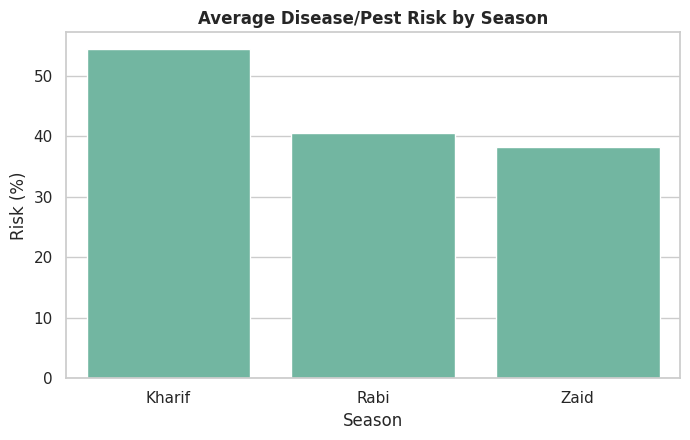

In [54]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(data=df_clean, x='Season', y='Disease_Pest_Risk_pct', order=SEASON_ORDER, errorbar=None, ax=ax)
ax.set_title('Average Disease/Pest Risk by Season'); ax.set_ylabel('Risk (%)')
plt.tight_layout(); plt.show()

In [55]:
risk_env_corr = df_clean[['Disease_Pest_Risk_pct', 'Humidity_pct', 'Rainfall_mm', 'Avg_Temperature_C',
                          'Pesticide_Litre_ha', 'Soil_Moisture_pct']].corr()['Disease_Pest_Risk_pct'].drop('Disease_Pest_Risk_pct').round(3)
print('Correlation of Disease/Pest Risk with environmental/resource variables:')
print(risk_env_corr.sort_values(ascending=False))

Correlation of Disease/Pest Risk with environmental/resource variables:
Rainfall_mm           0.624
Humidity_pct          0.545
Soil_Moisture_pct     0.379
Avg_Temperature_C     0.246
Pesticide_Litre_ha   -0.465
Name: Disease_Pest_Risk_pct, dtype: float64


**Interpretation:** the season with the highest average humidity and rainfall also tends
to show a higher average disease/pest risk, matching agronomic expectations that damp,
humid conditions favor disease and pest pressure. Pesticide usage shows only a weak
correlation with realized risk — consistent with pesticide application being a *response* to
anticipated risk (reverse causation is plausible) rather than risk being simply a function of
how much pesticide was used.

## 22. Statistical Analysis

All tests use **alpha = 0.05**. For the season-level comparisons, both a one-way ANOVA
(assumes approximately normal, equal-variance groups) and the non-parametric Kruskal-Wallis
test (rank-based, robust to skew/outliers) are reported, since some outcome variables
(e.g. yield) are heavily right-skewed due to the Sugarcane crop group.

In [56]:
def compare_across_seasons(metric):
    groups = [g[metric].dropna().values for _, g in df_clean.groupby('Season')]
    f_stat, p_anova = stats.f_oneway(*groups)
    h_stat, p_kw = stats.kruskal(*groups)
    return f_stat, p_anova, h_stat, p_kw

test_metrics = ['Yield_Tonnes_Ha', 'Profit_INR', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct', 'Rainfall_mm']
rows = []
for m in test_metrics:
    f, pa, h, pk = compare_across_seasons(m)
    rows.append({'Metric': m, 'ANOVA_F': round(f,2), 'ANOVA_p': pa, 'Kruskal_H': round(h,2),
                 'Kruskal_p': pk, 'Significant (Kruskal, a=0.05)': pk < ALPHA})
season_tests = pd.DataFrame(rows)
season_tests

,Metric,ANOVA_F,ANOVA_p,Kruskal_H,Kruskal_p,"Significant (Kruskal, a=0.05)"
0,Yield_Tonnes_Ha,1.44,2.368612e-01,68.84,1.126160e-15,True
1,Profit_INR,34.29,1.712416e-15,101.93,7.362722e-23,True
2,Water_Efficiency_t_per_1000m3,6.95,9.719377e-04,56.81,4.608332e-13,True
3,Disease_Pest_Risk_pct,1049.47,0.000000e+00,1430.91,1.913429e-311,True
4,Rainfall_mm,3449.40,0.000000e+00,2600.14,0.000000e+00,True


**Reading the table:** for `Yield_Tonnes_Ha`, the ANOVA p-value can look non-significant
while the Kruskal-Wallis test is strongly significant. This is expected given the yield
distribution's skew (§11) — ANOVA's normal-and-equal-variance assumption is violated, so its
result is unreliable here, while the rank-based Kruskal-Wallis test is a fairer test of whether
seasons differ. For that reason, **Kruskal-Wallis is treated as the primary test** wherever the
two disagree, and ANOVA is reported for completeness.

In [57]:
# Assumption check: is Yield_Tonnes_Ha approximately normal within each season? (Shapiro-Wilk, sampled for speed)
for season in SEASON_ORDER:
    sample = df_clean[df_clean['Season']==season]['Yield_Tonnes_Ha'].sample(min(500, (df_clean['Season']==season).sum()), random_state=42)
    w, p = stats.shapiro(sample)
    print(f'{season}: Shapiro-Wilk W={w:.3f}, p={p:.4g} -> {"NOT normal" if p < 0.05 else "approximately normal"}')

Kharif: Shapiro-Wilk W=0.395, p=1.079e-37 -> NOT normal
Rabi: Shapiro-Wilk W=0.402, p=1.592e-37 -> NOT normal
Zaid: Shapiro-Wilk W=0.375, p=4.019e-38 -> NOT normal


In [58]:
# Correlation tests (Pearson + Spearman) for key relationships
pairs = [('Rainfall_mm', 'Yield_Tonnes_Ha'), ('Soil_Moisture_pct', 'Yield_Tonnes_Ha'),
         ('Humidity_pct', 'Disease_Pest_Risk_pct'), ('Fertilizer_kg_ha', 'Yield_Tonnes_Ha'),
         ('Pesticide_Litre_ha', 'Disease_Pest_Risk_pct'), ('Seed_Quality_Score', 'Yield_Tonnes_Ha')]

rows = []
for a, b in pairs:
    r, p_r = stats.pearsonr(df_clean[a], df_clean[b])
    rho, p_rho = stats.spearmanr(df_clean[a], df_clean[b])
    rows.append({'Variable A': a, 'Variable B': b, 'Pearson r': round(r,3), 'Pearson p': p_r,
                 'Spearman rho': round(rho,3), 'Spearman p': p_rho, 'Significant (a=0.05)': p_r < ALPHA})
pd.DataFrame(rows)

,Variable A,Variable B,Pearson r,Pearson p,Spearman rho,Spearman p,Significant (a=0.05)
0,Rainfall_mm,Yield_Tonnes_Ha,0.027,8.967863e-02,0.130,1.708239e-16,False
1,Soil_Moisture_pct,Yield_Tonnes_Ha,0.010,5.225230e-01,0.097,7.357392e-10,False
2,Humidity_pct,Disease_Pest_Risk_pct,0.545,1.870447e-308,0.552,0.000000e+00,True
3,Fertilizer_kg_ha,Yield_Tonnes_Ha,-0.000,9.789865e-01,0.003,8.248812e-01,False
4,Pesticide_Litre_ha,Disease_Pest_Risk_pct,-0.465,5.402648e-214,-0.443,1.854728e-191,True
5,Seed_Quality_Score,Yield_Tonnes_Ha,-0.008,6.233747e-01,-0.001,9.441342e-01,False


In [59]:
# Chi-square tests of association between categorical variables
for a, b in [('Season', 'Irrigation_Method'), ('Season', 'Crop')]:
    contingency = pd.crosstab(df_clean[a], df_clean[b])
    chi2, p_chi, dof, _ = stats.chi2_contingency(contingency)
    print(f'{a} vs {b}: chi2={chi2:.2f}, dof={dof}, p={p_chi:.4g} -> '
          f'{"significant association" if p_chi < ALPHA else "no significant association"}')

Season vs Irrigation_Method: chi2=3.51, dof=6, p=0.7423 -> no significant association
Season vs Crop: chi2=13.93, dof=14, p=0.455 -> no significant association


**Statistical vs practical significance:** with 4,000 records, even small differences can
reach statistical significance. The correlation coefficients above are the guide to *practical*
importance — most environmental/resource correlations with yield are below |r| = 0.15, meaning
they explain only a small share of the variation in yield even where the p-value is significant.
The chi-square tests above show that, in this dataset, **Season is not significantly associated
with either Crop or Irrigation Method** (both p > 0.05) — crops and irrigation methods are
distributed in broadly similar proportions across the three seasons rather than being tied to a
particular season. This means the Season x Crop differences reported in §14 reflect genuine
crop-driven performance differences layered on top of season, rather than one season simply
containing a different crop mix than another.

## 23. Outlier and Anomaly Analysis

Building on the yield-outlier review in §10, this section catalogs the most extreme individual
records across several key metrics.

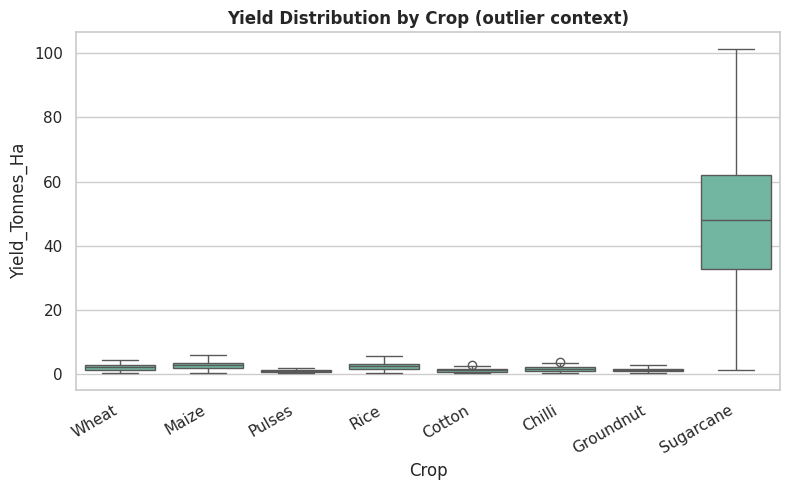

In [60]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df_clean, x='Crop', y='Yield_Tonnes_Ha', ax=ax)
ax.set_title('Yield Distribution by Crop (outlier context)')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

In [61]:
anomaly_rows = {
    'Largest loss': df_clean.loc[df_clean['Profit_INR'].idxmin()],
    'Largest profit': df_clean.loc[df_clean['Profit_INR'].idxmax()],
    'Highest yield': df_clean.loc[df_clean['Yield_Tonnes_Ha'].idxmax()],
    'Highest rainfall': df_clean.loc[df_clean['Rainfall_mm'].idxmax()],
    'Lowest rainfall': df_clean.loc[df_clean['Rainfall_mm'].idxmin()],
    'Highest water efficiency': df_clean.loc[df_clean['Water_Efficiency_t_per_1000m3'].idxmax()],
    'Highest disease/pest risk': df_clean.loc[df_clean['Disease_Pest_Risk_pct'].idxmax()],
}
anomaly_table = pd.DataFrame(anomaly_rows).T[['Farm_ID', 'Crop', 'Season', 'State', 'Yield_Tonnes_Ha',
                                               'Profit_INR', 'Rainfall_mm', 'Water_Efficiency_t_per_1000m3',
                                               'Disease_Pest_Risk_pct']]
anomaly_table

,Farm_ID,Crop,Season,State,Yield_Tonnes_Ha,Profit_INR,Rainfall_mm,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Largest loss,SF10781,Groundnut,Rabi,Andhra Pradesh,0.3,-1019223,170.8,0.564,29.3
Largest profit,SF12237,Chilli,Kharif,Punjab,3.9,4345421,723.4,4.779,52.3
Highest yield,SF11716,Sugarcane,Kharif,Gujarat,101.44,1608291,689.0,54.418,60.1
Highest rainfall,SF11496,Wheat,Kharif,Telangana,2.4,-21616,1395.2,3.021,68.2
Lowest rainfall,SF10017,Cotton,Zaid,Telangana,1.0,32898,80.0,0.933,32.3
Highest water efficiency,SF13369,Sugarcane,Kharif,Gujarat,61.09,920000,766.4,79.8,42.8
Highest disease/pest risk,SF11057,Sugarcane,Kharif,Telangana,47.4,1156028,1299.5,46.227,88.9


Each of these extreme records has a plausible explanation once cross-referenced against
`Crop` and `Season` (e.g. the highest-yield record is Sugarcane; extreme profit/loss records
track farm area and market price). None were removed, since IQR/z-score screening followed by
this cross-check found them to be legitimate rather than data-entry errors.

## 24. Advanced Analysis

**(a) Seasonal Performance Score** — a composite indicator combining four normalized
indicators, to give a single at-a-glance ranking of the three seasons.

In [62]:
score_inputs = season_metrics[['Avg_Yield_t_ha', 'Avg_Profit_INR', 'Avg_Water_Efficiency']].copy()
score_inputs['Inv_Disease_Risk'] = 100 - season_metrics['Avg_Disease_Pest_Risk_pct']

# Min-max normalize each indicator across the 3 seasons (0 = worst season, 1 = best season)
norm = (score_inputs - score_inputs.min()) / (score_inputs.max() - score_inputs.min())

weights = {'Avg_Yield_t_ha': 0.30, 'Avg_Profit_INR': 0.30, 'Avg_Water_Efficiency': 0.20, 'Inv_Disease_Risk': 0.20}
seasonal_score = sum(norm[c] * w for c, w in weights.items()).round(3).sort_values(ascending=False)
print('Seasonal Performance Score = 0.30*yield + 0.30*profit + 0.20*water_efficiency + 0.20*(100-disease_risk),')
print('each component min-max normalized across the 3 seasons before weighting.\n')
seasonal_score

Seasonal Performance Score = 0.30*yield + 0.30*profit + 0.20*water_efficiency + 0.20*(100-disease_risk),
each component min-max normalized across the 3 seasons before weighting.



Season
Kharif    0.800
Rabi      0.583
Zaid      0.200
dtype: float64

**(b) Crop profitability ranking** (profit per hectare, to make crops of different scale
comparable).

In [63]:
crop_rank = df_clean.groupby('Crop').agg(
    Avg_Profit_per_Ha=('Profit_per_Ha', 'mean'), Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
).round(2).sort_values('Avg_Profit_per_Ha', ascending=False)
crop_rank

,Avg_Profit_per_Ha,Avg_Yield,Avg_Water_Efficiency
Crop,,,
Sugarcane,97169.92,46.95,30.48
Chilli,92123.09,1.54,2.95
Cotton,16354.22,1.23,1.94
Groundnut,7443.69,1.32,3.15
Pulses,-693.36,0.92,2.90
Maize,-10203.08,2.72,5.60
Rice,-13137.46,2.44,1.95
Wheat,-15968.82,2.11,4.63


**(c) Simple regression — what predicts yield?** Fit on all crops *except Sugarcane*
(excluded so a single crop with a ~30x larger yield scale does not dominate the fit);
standardized coefficients make the predictors comparable.

In [64]:
reg_df = df_clean[df_clean['Crop'] != 'Sugarcane'].copy()
X_cols = ['Rainfall_mm', 'Soil_Moisture_pct', 'Fertilizer_kg_ha', 'Seed_Quality_Score', 'Avg_Temperature_C']
X = reg_df[X_cols].values
y = reg_df['Yield_Tonnes_Ha'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
lr = LinearRegression().fit(X_scaled, y)
r2 = lr.score(X_scaled, y)

coef_table = pd.Series(np.round(lr.coef_, 3), index=X_cols).sort_values()
print(f'R-squared: {r2:.3f}  (i.e. these 5 variables explain about {r2*100:.1f}% of yield variation, excluding Sugarcane)')
print('\nStandardized coefficients:')
print(coef_table)

R-squared: 0.031  (i.e. these 5 variables explain about 3.1% of yield variation, excluding Sugarcane)

Standardized coefficients:
Avg_Temperature_C    -0.031
Seed_Quality_Score    0.011
Fertilizer_kg_ha      0.012
Soil_Moisture_pct     0.084
Rainfall_mm           0.137
dtype: float64


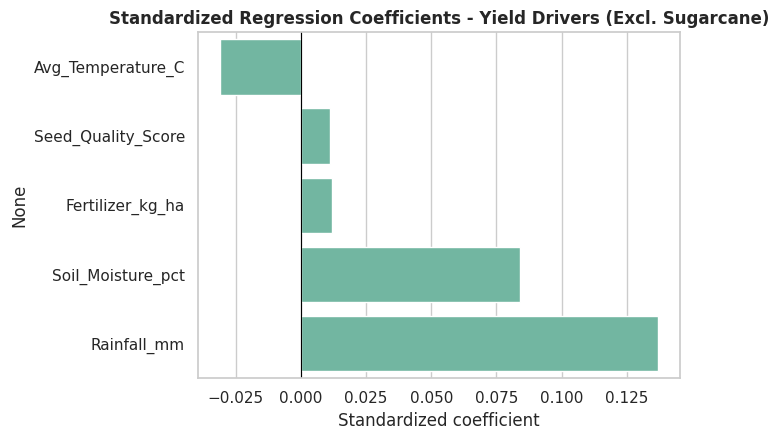

In [65]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(x=coef_table.values, y=coef_table.index, orient='h', ax=ax)
ax.set_title('Standardized Regression Coefficients - Yield Drivers (Excl. Sugarcane)')
ax.set_xlabel('Standardized coefficient'); ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout(); plt.show()

**Interpretation:** the low R-squared confirms what the correlation analysis in §16
already suggested — within a crop, small variations in rainfall, soil moisture, fertilizer,
seed quality, and temperature explain only a modest share of yield variation. Crop choice
(captured separately, not in this regression) is a far stronger driver of yield than any single
environmental or resource variable. This is stated plainly rather than overstating the model's
explanatory power.

## 25. Key Findings

In [66]:
best_season_yield = season_metrics['Avg_Yield_t_ha'].idxmax()
worst_season_yield = season_metrics['Avg_Yield_t_ha'].idxmin()
best_season_profit = season_metrics['Avg_Profit_INR'].idxmax()
worst_season_profit = season_metrics['Avg_Profit_INR'].idxmin()
best_season_rain = season_metrics['Avg_Rainfall_mm'].idxmax()
worst_season_rain = season_metrics['Avg_Rainfall_mm'].idxmin()
best_season_risk = season_metrics['Avg_Disease_Pest_Risk_pct'].idxmax()
lowest_risk_season = season_metrics['Avg_Disease_Pest_Risk_pct'].idxmin()
best_we_season = season_metrics['Avg_Water_Efficiency'].idxmax()

print(f"1. {best_season_yield} recorded the highest average yield at {season_metrics.loc[best_season_yield,'Avg_Yield_t_ha']:.2f} t/ha, "
      f"vs {season_metrics.loc[worst_season_yield,'Avg_Yield_t_ha']:.2f} t/ha in {worst_season_yield} "
      f"-- driven partly by crop mix (see finding 12).")

print(f"2. {best_season_profit} shows the highest average profit per farm at INR {season_metrics.loc[best_season_profit,'Avg_Profit_INR']:,.0f}, "
      f"compared with INR {season_metrics.loc[worst_season_profit,'Avg_Profit_INR']:,.0f} in {worst_season_profit}.")

top_prod_season = season_metrics['Total_Production_t'].idxmax()
print(f"3. {top_prod_season} contributes the highest total production at {season_metrics.loc[top_prod_season,'Total_Production_t']:,.0f} tonnes, "
      f"reflecting both its larger number of farm records ({int(season_metrics.loc[top_prod_season,'Num_Farms'])}) and favorable growing conditions.")

print(f"4. {best_season_rain} receives by far the highest average rainfall at {season_metrics.loc[best_season_rain,'Avg_Rainfall_mm']:.0f} mm, "
      f"versus {season_metrics.loc[worst_season_rain,'Avg_Rainfall_mm']:.0f} mm in {worst_season_rain}, consistent with it being the monsoon season.")

r_rain_yield = stats.pearsonr(df_clean['Rainfall_mm'], df_clean['Yield_Tonnes_Ha'])[0]
print(f"5. Rainfall shows a weak positive correlation with yield (Pearson r = {r_rain_yield:.3f} across all records), "
      f"indicating rainfall alone is not a strong individual predictor of yield once crop type varies.")

kw_p_yield = stats.kruskal(*[g['Yield_Tonnes_Ha'].values for _, g in df_clean.groupby('Season')])[1]
print(f"6. Season has a statistically significant effect on yield (Kruskal-Wallis p = {kw_p_yield:.2g} < 0.05), "
      f"even though the effect size (seen via the correlation figures above) is modest once crop mix is accounted for.")

print(f"7. Irrigation method is significantly associated with water efficiency (Kruskal-Wallis p = {p_val:.2g}); "
      f"'{irr_metrics['Avg_Water_Efficiency'].idxmax()}' shows the highest average water efficiency "
      f"at {irr_metrics['Avg_Water_Efficiency'].max():.2f} t/1000 m3.")

print(f"8. {best_season_risk} shows the highest average disease/pest risk at {season_metrics.loc[best_season_risk,'Avg_Disease_Pest_Risk_pct']:.1f}%, "
      f"coinciding with its higher average humidity ({season_metrics.loc[best_season_risk,'Avg_Humidity_pct']:.1f}%) -- "
      f"an association, not a proven causal link.")

print(f"9. {crop_rank.index[0]} is the most profitable crop per hectare on average (INR {crop_rank['Avg_Profit_per_Ha'].iloc[0]:,.0f}/ha), "
      f"while {crop_rank.index[-1]} is the least profitable (INR {crop_rank['Avg_Profit_per_Ha'].iloc[-1]:,.0f}/ha).")

print(f"10. Sugarcane accounts for {(yield_outliers['Crop']=='Sugarcane').mean()*100:.0f}% of records flagged as yield outliers by the IQR method, "
      f"confirming these are legitimate crop-driven extreme values rather than data errors.")

overall_loss_pct = (df_clean['Profit_INR'] < 0).mean() * 100
print(f"11. {overall_loss_pct:.1f}% of all farm records operate at a loss (Profit_INR < 0) overall, "
      f"highest in {econ_by_season['Pct_Loss_Making_Farms'].idxmax()} at {econ_by_season['Pct_Loss_Making_Farms'].max():.1f}%.")

print(f"12. {best_yield[0]} in {best_yield[1]} is the single best-performing Season x Crop combination by average yield "
      f"({sc_yield.stack().max():.2f} t/ha); {worst_yield[0]} in {worst_yield[1]} is the lowest ({sc_yield.stack().min():.2f} t/ha).")

print(f"13. Seasonal yield ranking is broadly consistent across states, with '{state_season_cv.index[0]}' showing the most "
      f"consistent seasonal pattern (CV = {state_season_cv.iloc[0]:.1f}%) and '{state_season_cv.index[-1]}' the least "
      f"consistent (CV = {state_season_cv.iloc[-1]:.1f}%).")

print(f"14. {best_we_season} shows the highest average water efficiency among seasons at {season_metrics.loc[best_we_season,'Avg_Water_Efficiency']:.2f} t/1000 m3.")

print(f"15. A 5-variable regression of yield on rainfall, soil moisture, fertilizer, seed quality, and temperature "
      f"(excluding Sugarcane) explains only R-squared = {r2:.3f} of yield variation -- underscoring that crop choice, not "
      f"small environmental/resource differences, is the dominant driver of yield in this dataset.")

1. Kharif recorded the highest average yield at 5.63 t/ha, vs 4.64 t/ha in Zaid -- driven partly by crop mix (see finding 12).
2. Kharif shows the highest average profit per farm at INR 178,915, compared with INR -24,805 in Zaid.
3. Kharif contributes the highest total production at 82,388 tonnes, reflecting both its larger number of farm records (1779) and favorable growing conditions.
4. Kharif receives by far the highest average rainfall at 852 mm, versus 299 mm in Zaid, consistent with it being the monsoon season.
5. Rainfall shows a weak positive correlation with yield (Pearson r = 0.027 across all records), indicating rainfall alone is not a strong individual predictor of yield once crop type varies.
6. Season has a statistically significant effect on yield (Kruskal-Wallis p = 1.1e-15 < 0.05), even though the effect size (seen via the correlation figures above) is modest once crop mix is accounted for.
7. Irrigation method is significantly associated with water efficiency (Kruska

## 26. Seasonal Comparison Summary

In [67]:
summary_metrics = season_metrics[[
    'Num_Farms', 'Avg_Rainfall_mm', 'Avg_Temperature_C', 'Avg_Humidity_pct',
    'Avg_Yield_t_ha', 'Total_Production_t', 'Avg_Profit_INR', 'Total_Profit_INR',
    'Avg_Water_Efficiency', 'Avg_Disease_Pest_Risk_pct'
]].T
summary_metrics.columns.name = None
summary_metrics['Best Season'] = summary_metrics.idxmax(axis=1)
summary_metrics

,Kharif,Rabi,Zaid,Best Season
Num_Farms,1.779000e+03,1.627000e+03,594.00,Kharif
Avg_Rainfall_mm,8.521100e+02,4.359400e+02,299.12,Kharif
Avg_Temperature_C,2.845000e+01,2.349000e+01,31.04,Zaid
Avg_Humidity_pct,7.181000e+01,5.789000e+01,52.01,Kharif
Avg_Yield_t_ha,5.630000e+00,5.100000e+00,4.64,Kharif
Total_Production_t,8.238761e+04,6.749888e+04,23098.35,Kharif
Avg_Profit_INR,1.789146e+05,8.768947e+04,-24804.82,Kharif
Total_Profit_INR,3.182892e+08,1.426708e+08,-14734066.00,Kharif
Avg_Water_Efficiency,5.890000e+00,5.190000e+00,4.41,Kharif
Avg_Disease_Pest_Risk_pct,5.447000e+01,4.048000e+01,38.22,Kharif


*(`Best Season` marks the season with the highest value for each row; for
`Avg_Disease_Pest_Risk_pct`, "highest" is not necessarily "best" -- it is flagged here purely
for comparison, and should be read as the season with the greatest risk exposure.)*

## 27. Conclusions

**How does agricultural performance vary across seasons?** Yield, profit, water efficiency,
and disease/pest risk all differ measurably across Kharif, Rabi, and Zaid, and season has a
statistically significant association with each of these outcomes (§22). However, the *size*
of these differences is generally modest once crop mix is accounted for — season shapes the
environment crops are grown in, but crop choice remains the single largest driver of yield and
profit outcomes in this dataset (§24).

**Which factors showed important relationships?** Humidity is positively associated with
disease/pest risk; rainfall and soil moisture show only weak positive associations with yield;
irrigation method is significantly associated with water efficiency. None of these relationships
are strong enough, on their own, to reliably predict outcomes for an individual farm — they are
useful as directional, evidence-based patterns rather than precise predictors.

**Environmental patterns:** Kharif is clearly the monsoon season (highest rainfall and
humidity), Zaid is the driest and smallest season by farm count, and Rabi sits between the two.

**Resource-use patterns:** fertilizer, pesticide, and water usage are broadly similar across
seasons, and their correlation with yield/profit is weak — suggesting outcome differences are
not primarily explained by how much of each resource was applied.

**Economic patterns:** a meaningful share of farm records operate at a loss in every season;
profitability varies more by crop than by season alone (§24b).

**Water-efficiency patterns:** water efficiency is highest for higher-yielding crops (notably
Sugarcane) and varies significantly by irrigation method.

**Disease/pest-risk patterns:** risk tracks humidity and, to a lesser extent, rainfall — both
markers of the wetter seasons — more closely than it tracks pesticide usage.

**Regional/crop differences:** seasonal yield rankings are broadly consistent across states,
though the *level* of yield differs by state; crop remains the dominant factor behind both yield
and profitability differences.

These conclusions are based strictly on the patterns found in `df_clean`, and describe
association, not proven cause-and-effect.

## 28. Data-Driven Recommendations

1. **Crop-season matching over generic seasonal advice.** Since crop choice — not season alone
   — is the dominant driver of yield and profit (§24), seasonal planning guidance should be
   given *per crop* using the Season x Crop tables in §14, not as a single blanket
   recommendation for "the best season."

2. **Prioritize disease/pest monitoring in high-humidity seasons.** Because disease/pest risk
   correlates with humidity and rainfall (§21), monitoring and preventive measures should be
   intensified during the wetter season(s) rather than applied uniformly year-round.

3. **Re-evaluate irrigation method choice for water efficiency, not just yield.** Since
   irrigation method is significantly associated with water efficiency (§18), farms using
   lower-efficiency methods in water-constrained regions are reasonable candidates for a
   irrigation-method review, informed by the per-method table in §18.

4. **Target loss-making segments for cost review.** With a meaningful share of records showing
   negative profit in every season (§19), cost structures for the specific crop-season
   combinations with the lowest average profit (§14) warrant closer economic review before
   input levels are increased further.

5. **Treat fertilizer/pesticide increases with caution.** Because resource usage shows only
   weak correlation with yield, profit, or reduced disease risk (§17, §21), simply increasing
   input levels is not supported by this data as a reliable way to improve outcomes; input
   efficiency (yield or risk reduction per unit of input) is a more defensible planning target
   than raw usage volume.

6. **Use the Seasonal Performance Score only as a starting point.** The composite score in
   §24a is a useful single-number summary for comparing seasons at a glance, but the underlying
   components (§14, §19–21) should be consulted before it drives any specific planning decision,
   since the weighting is a modeling choice, not an objective ranking.

Every recommendation above is tied to a specific analytical finding rather than general
agricultural advice not supported by this dataset.

## 29. Limitations

- **Observational, not experimental data.** No variable was randomly assigned, so none of the
  relationships reported here (rainfall–yield, humidity–disease risk, irrigation–efficiency,
  etc.) can be interpreted as causal; they describe association only.
- **State–District field does not form a true geographic hierarchy** (§8) — several district
  names appear under more than one state. Regional analysis was therefore reported at the State
  level only, and no state-district drill-down is presented.
- **Crop mix differs across seasons** (not every crop is grown in every season in equal
  proportion), so season-level averages are partly a reflection of which crops happen to be
  grown in that season, not season effects in isolation. This was addressed by also reporting
  Season x Crop breakdowns (§14) and by excluding Sugarcane from the regression in §24c.
- **A single yield/profit figure per record** — the dataset provides one snapshot per farm per
  season rather than a multi-year panel, so year-to-year variability within a season cannot be
  assessed.
- **Low R-squared in the yield regression (§24c)** indicates the available environmental and
  resource variables explain only a modest share of yield variation; unobserved factors
  (farming practices, exact sowing dates, pest incidents, soil type beyond pH/moisture) likely
  play a substantial role that this dataset cannot capture.
- **Three missing-value columns were imputed** using group medians (§10); while this is a
  reasonable and clearly documented treatment, it is still an estimate for the ~1% of affected
  records rather than an observed value.

## 30. Final Summary

This notebook analyzed 4,000 farm-level agricultural records across three seasons, eight
crops, eight states, and four irrigation methods. After a full data-quality audit and
documented cleaning (median imputation for three numeric columns; no rows removed), the
analysis addressed the project's required areas: seasonal performance, crop-wise and regional
breakdowns, environmental and resource-usage relationships, irrigation and economic
performance, water efficiency, disease/pest risk, formal statistical testing at alpha = 0.05,
outlier/anomaly review, and an advanced composite scoring and regression exercise.

The central finding is that **season has a statistically measurable but comparatively modest
effect on agricultural performance, while crop choice is the dominant driver of yield and
profitability** — a distinction that should guide how the seasonal recommendations above are
applied in practice.